# MODELO DE CLASIFICACIÓN ENFERMEDADES RELACIONADAS CON EL SUEÑO - ESTIMACIÓN DEL RIESGO DE APNEA

Al observar que la extracción de datos únicamente de fuente propia mediante el O2Ring resultaba muy costoso, se ha optado por tomar un dataset ya existente que cumple con las características que se requiere. (Dataset de kaggle)

Se tratará de generar un modelo de clasificación para la estimación del riesgo de padecer apnea del sueño u otras enfermedades relacionadas con el sueño.

## 1. IMPORTACIÓN DE LOS DATOS Y PRIMERAS VISUALIZACIONES

CARGAR LIBRERÍAS NECESARIAS

In [39]:
# Carga de las librerías necesarias
import pandas as pd
import numpy as np

# Para visualizar mejor los datos
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE


# Configuración de gráficos
sns.set(style="whitegrid")

CARGAR EL DATASET

In [40]:
ruta = r"C:\Users\Marina\OneDrive - Universidad de Burgos\Escritorio\TFG-Marina-Martin\datos\Sleep_health_and_lifestyle_dataset.csv"

# Cargar el dataset
df = pd.read_csv(ruta)

# Mostrar las primeras filas
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


REVISAR INFORMACIÓN GENERAL

In [41]:
# Ver información general sobre las columnas y tipos de datos
df.info()

# Ver valores nulos en el dataset
print("\nValores nulos en cada columna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB

Valores nulos en cada

In [42]:
df.duplicated().sum()

0

INFORMACIÓN GENERAL DEL DATASET

In [43]:
# Ver información general sobre las columnas y tipos de datos
df.info()

# Ver valores nulos en el dataset
print("\nValores nulos en cada columna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB

Valores nulos en cada

DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS

In [44]:
# Resumen estadístico de las columnas numéricas
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


REVISAR VALORES ÚNICOS EN LAS VARIABLES CATEGÓRICAS

In [45]:
# Ver los valores únicos de cada variable categórica
categorical_columns = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']
for col in categorical_columns:
    print(f"\n{col} - Valores únicos:")
    print(df[col].unique())



Gender - Valores únicos:
['Male' 'Female']

Occupation - Valores únicos:
['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager']

BMI Category - Valores únicos:
['Overweight' 'Normal' 'Obese' 'Normal Weight']

Sleep Disorder - Valores únicos:
['None' 'Sleep Apnea' 'Insomnia']


## 2. ANÁLISIS ESTADISTICO

A) VARIABLES NUMÉRICAS

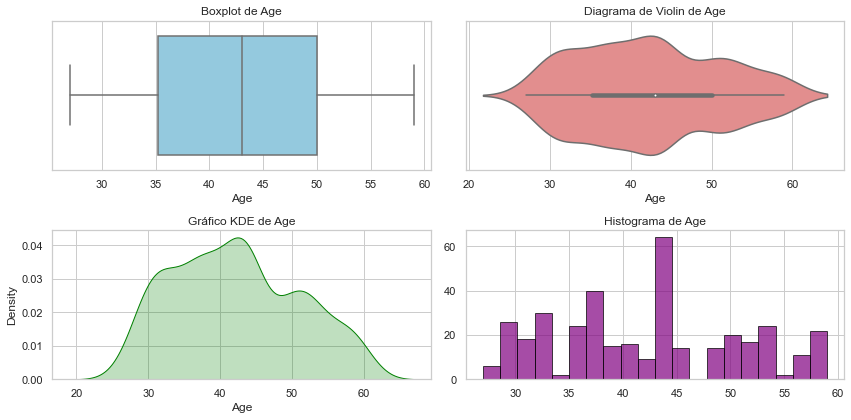

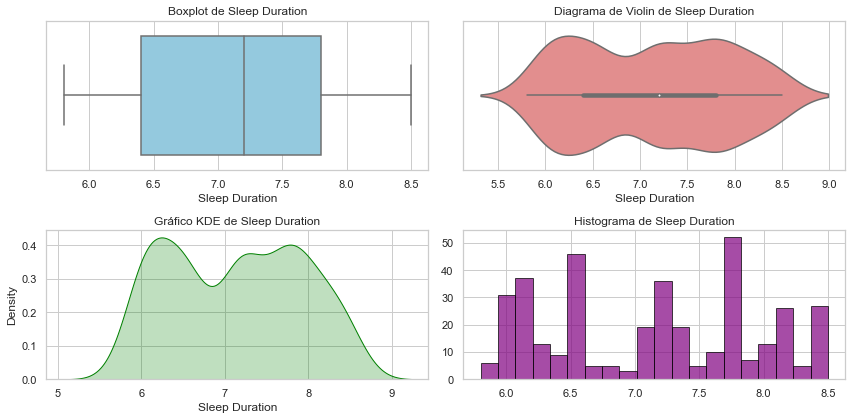

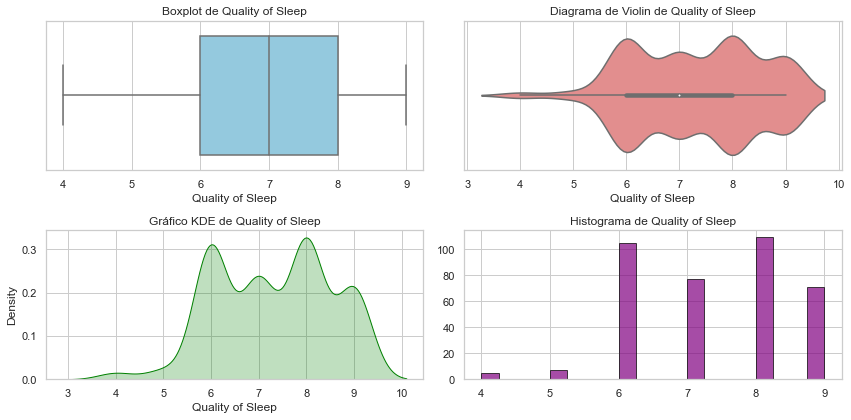

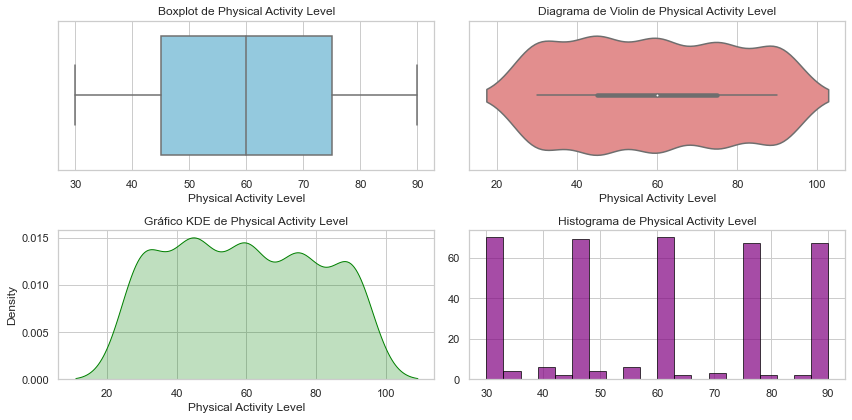

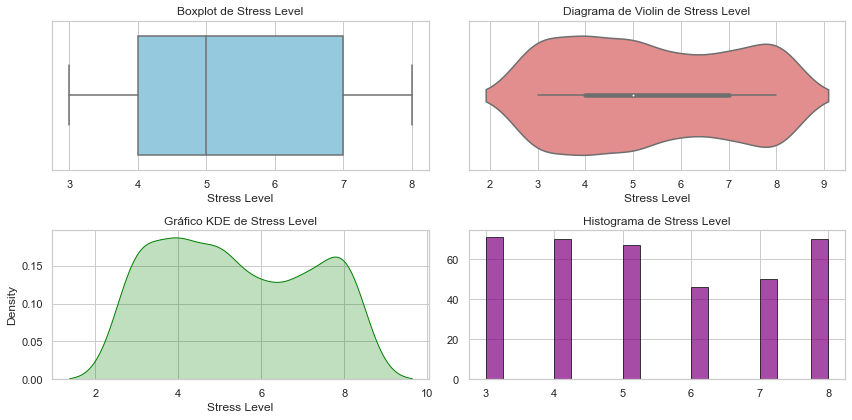

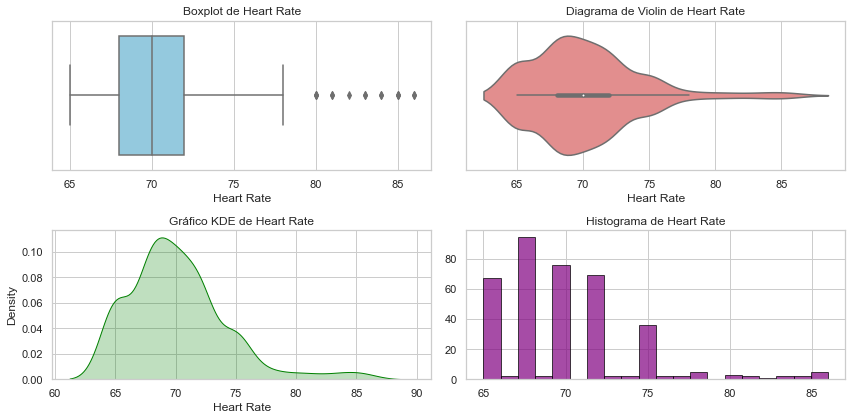

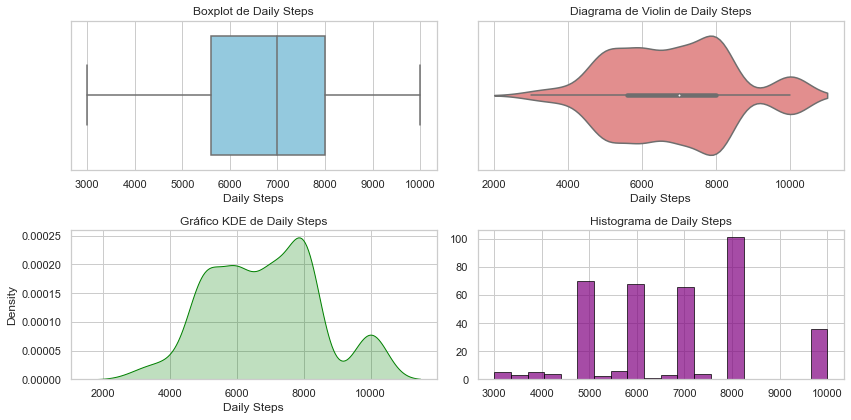

In [46]:
# Definir las variables numéricas
numerical_columns = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 
                     'Stress Level', 'Heart Rate', 'Daily Steps']

# Crear los gráficos
for col in numerical_columns:
    plt.figure(figsize=(12, 6))
    
    # Boxplot con hue
    plt.subplot(2, 2, 1)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot de {col}")

    # Violin plot
    plt.subplot(2, 2, 2)
    sns.violinplot(x=df[col], color="lightcoral")
    plt.title(f"Diagrama de Violin de {col}")

    # KDE plot
    plt.subplot(2, 2, 3)
    sns.kdeplot(df[col], fill=True, color="green")
    plt.title(f"Gráfico KDE de {col}")

    # Histograma
    plt.subplot(2, 2, 4)
    plt.hist(df[col], bins=20, color="purple", alpha=0.7, edgecolor="black")
    plt.title(f"Histograma de {col}")

    plt.tight_layout()
    plt.show()

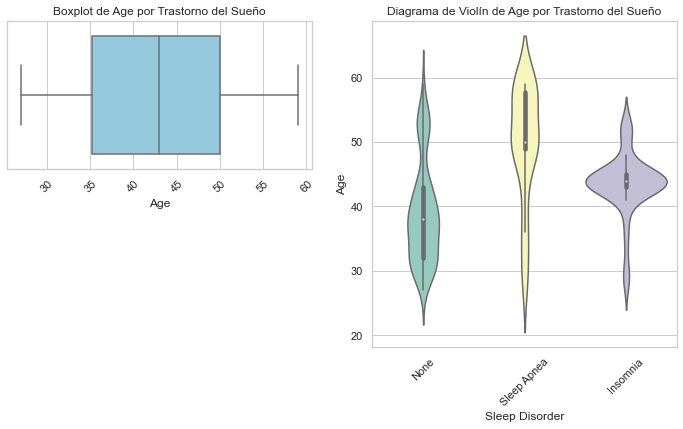

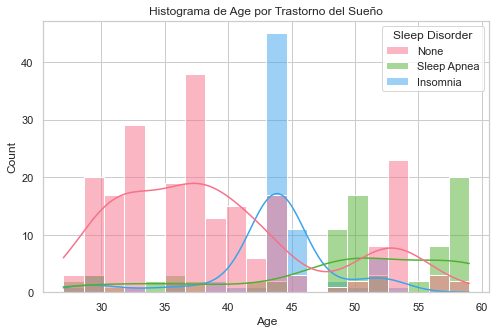

<Figure size 432x288 with 0 Axes>

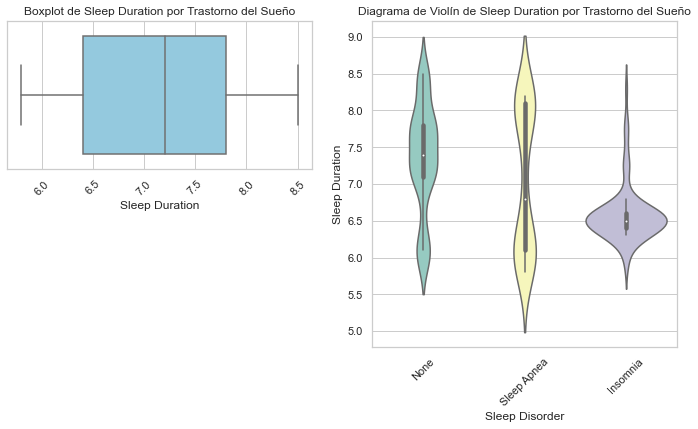

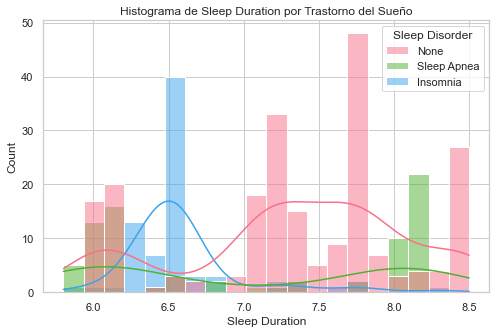

<Figure size 432x288 with 0 Axes>

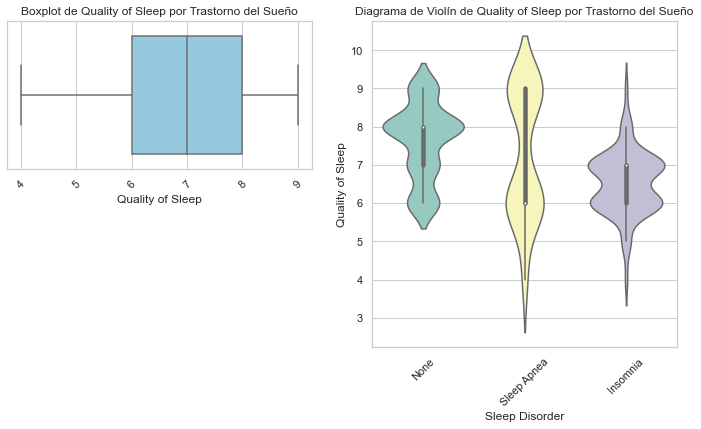

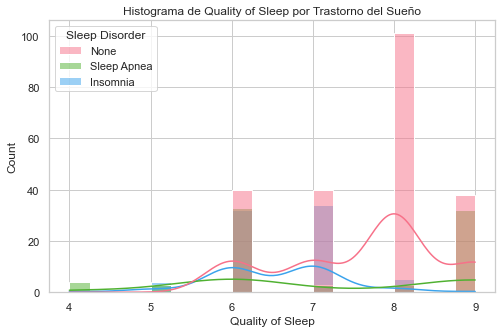

<Figure size 432x288 with 0 Axes>

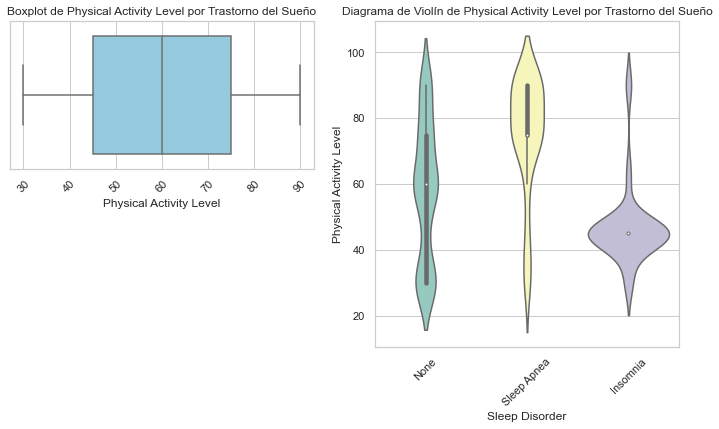

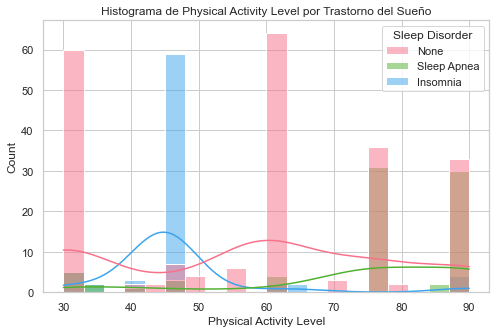

<Figure size 432x288 with 0 Axes>

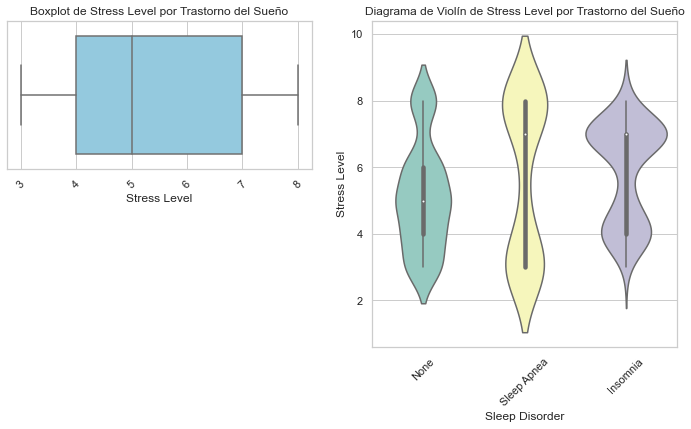

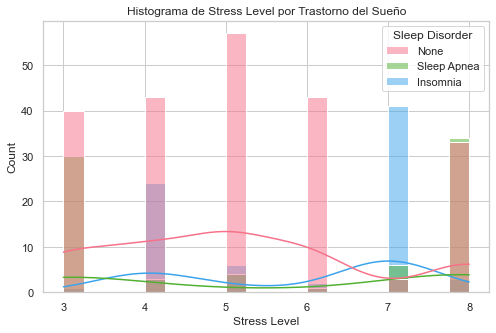

<Figure size 432x288 with 0 Axes>

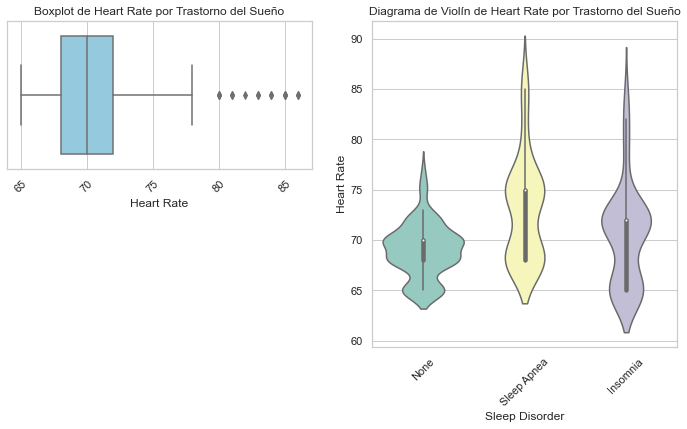

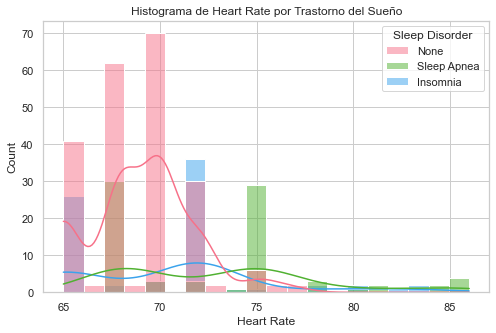

<Figure size 432x288 with 0 Axes>

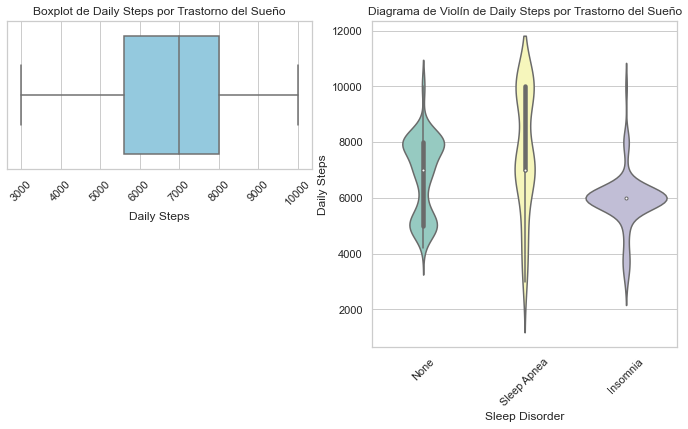

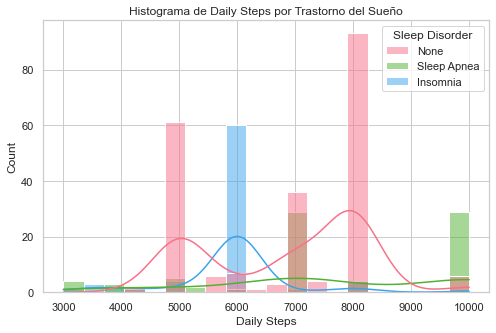

<Figure size 432x288 with 0 Axes>

In [47]:
# DIFERENCIANDO POR TRASTORNOS DEL SUEÑO
for col in numerical_columns:
    plt.figure(figsize=(12, 6))
    
    # Boxplot con hue
    plt.subplot(2, 2, 1)
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Boxplot de {col} por Trastorno del Sueño")
    plt.xticks(rotation=45)
    
    # Violin Plot con hue
    plt.subplot(1, 2, 2)
    sns.violinplot(x=df["Sleep Disorder"], y=df[col], palette="Set3")
    plt.title(f"Diagrama de Violín de {col} por Trastorno del Sueño")
    plt.xticks(rotation=45)
    
    # Histograma con hue
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=col, hue="Sleep Disorder", kde=True, bins=20, palette="husl")
    plt.title(f"Histograma de {col} por Trastorno del Sueño")
    plt.show()
    

    plt.tight_layout()
    plt.show()

B) VARIABLES CATEGÓRICAS

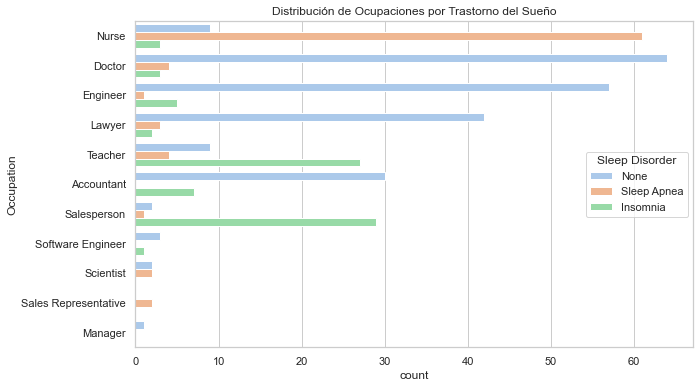

In [48]:
plt.figure(figsize=(10, 6))
sns.countplot(y=df["Occupation"], hue=df["Sleep Disorder"], palette="pastel", order=df["Occupation"].value_counts().index)
plt.title("Distribución de Ocupaciones por Trastorno del Sueño")
plt.show()

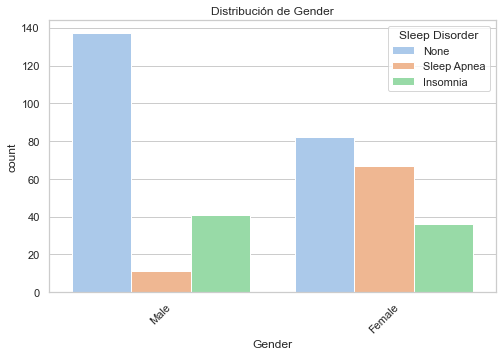

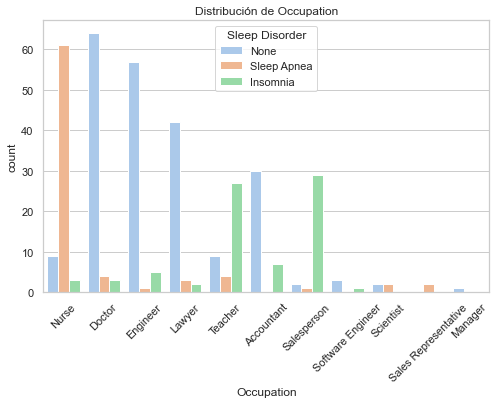

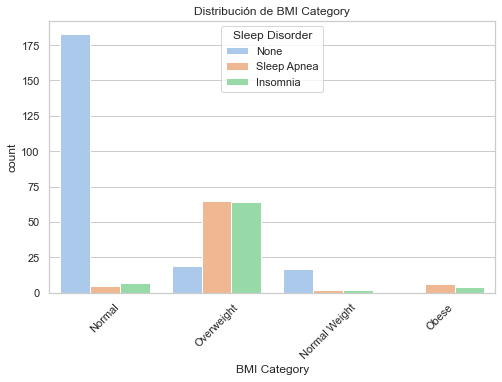

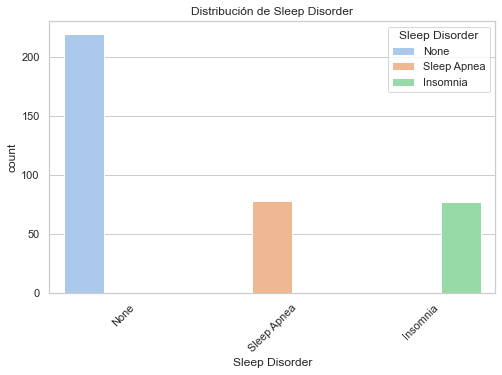

In [49]:
# Definir las variables categóricas
categorical_columns = ['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

for col in categorical_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[col], hue=df["Sleep Disorder"], palette="pastel", order=df[col].value_counts().index)
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)  # Girar etiquetas si es necesario
    plt.show()


OUTLIERS

In [50]:
# Detectar outliers en variables numéricas usando el método IQR
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 
                  'Physical Activity Level', 'Stress Level', 
                  'Heart Rate', 'Daily Steps']

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

# Definir umbrales para detectar outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Contar cuántos outliers hay por variable
outliers_count = ((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound)).sum()
print("Número de outliers por variable:\n", outliers_count)

# Identificar las filas con outliers sin eliminarlas
outliers = df[((df[numerical_cols] < lower_bound) | (df[numerical_cols] > upper_bound)).any(axis=1)]
print(f"Número total de filas con al menos un outlier: {outliers.shape[0]}")


Número de outliers por variable:
 Age                         0
Sleep Duration              0
Quality of Sleep            0
Physical Activity Level     0
Stress Level                0
Heart Rate                 15
Daily Steps                 0
dtype: int64
Número total de filas con al menos un outlier: 15


## 3. CONVERSIÓN DE VARIABLES CATEGÓRICAS

- Se utilizará **Label Encoding** en las variables categóricas que sean de tipo **ordinal**, es decir, en aquellas en las que el peso cobra relevancia.
- **One-Hot Encoding** se utilizará para variables categóricas que sean binarias o que no tenga ningún "peso" el valor de la misma (variables **nominales**, sin orden).

https://www.analyticsvidhya.com/blog/2020/03/one-hot-encoding-vs-label-encoding-using-scikit-learn/#h-what-is-label-encoding

3.1 ONE-HOT ENCODING PARA VARIABLES NOMINALES

In [51]:
from sklearn.preprocessing import OneHotEncoder

# Variables nominales a transformar
nominal_cols = ['Gender', 'Occupation']

encoder = OneHotEncoder(drop='first', sparse=False)  # Elimina una categoría para evitar colinealidad
encoded_nominal = pd.DataFrame(encoder.fit_transform(df[nominal_cols]), 
                               columns=encoder.get_feature_names_out(nominal_cols))

# Concatenamos al dataframe y eliminamos las columnas originales
df = pd.concat([df.drop(columns=nominal_cols), encoded_nominal], axis=1)


C:\Users\Marina\anaconda3\lib\site-packages\sklearn\preprocessing\_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


3.2 LABEL ENCODING PARA VARIABLES ORDINALES

In [52]:
df.head(30)

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,1,27,6.1,6,42,6,Overweight,126/83,77,4200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2,28,6.2,6,60,8,Normal,125/80,75,10000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,28,6.2,6,60,8,Normal,125/80,75,10000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,28,5.9,4,30,8,Obese,140/90,85,3000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,5,28,5.9,4,30,8,Obese,140/90,85,3000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,6,28,5.9,4,30,8,Obese,140/90,85,3000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,7,29,6.3,6,40,7,Obese,140/90,82,3500,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
7,8,29,7.8,7,75,6,Normal,120/80,70,8000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,9,29,7.8,7,75,6,Normal,120/80,70,8000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,10,29,7.8,7,75,6,Normal,120/80,70,8000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [53]:
print(df['BMI Category'].unique())

['Overweight' 'Normal' 'Obese' 'Normal Weight']


In [54]:
from sklearn.preprocessing import LabelEncoder

# Mapeo manual para asegurarnos del orden correcto
bmi_mapping = {'Normal Weight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
df['BMI Category'] = df['BMI Category'].map(bmi_mapping)

In [55]:
df.columns

Index(['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category',
       'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse',
       'Occupation_Sales Representative', 'Occupation_Salesperson',
       'Occupation_Scientist', 'Occupation_Software Engineer',
       'Occupation_Teacher'],
      dtype='object')

In [56]:
print(df.columns)

Index(['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'BMI Category',
       'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder',
       'Gender_Male', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Manager', 'Occupation_Nurse',
       'Occupation_Sales Representative', 'Occupation_Salesperson',
       'Occupation_Scientist', 'Occupation_Software Engineer',
       'Occupation_Teacher'],
      dtype='object')


In [57]:
# Ver valores nulos en el dataset
print("\nValores nulos en cada columna:")
print(df.isnull().sum())


Valores nulos en cada columna:
Person ID                          0
Age                                0
Sleep Duration                     0
Quality of Sleep                   0
Physical Activity Level            0
Stress Level                       0
BMI Category                       0
Blood Pressure                     0
Heart Rate                         0
Daily Steps                        0
Sleep Disorder                     0
Gender_Male                        0
Occupation_Doctor                  0
Occupation_Engineer                0
Occupation_Lawyer                  0
Occupation_Manager                 0
Occupation_Nurse                   0
Occupation_Sales Representative    0
Occupation_Salesperson             0
Occupation_Scientist               0
Occupation_Software Engineer       0
Occupation_Teacher                 0
dtype: int64


CONVERTIMOS LA PRESIÓN ARTERIAL EN VALORES NUMÉRICOS SEPARADOS

La presión sanguínea en el dataset está en una única celda, por lo que tenemos que dividirla en **sistólica** y **diastólica** y convertirla en tipo numérica.

In [58]:
 # División de las presiones en dos columnas:
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True)
    
# Conversión en tipo numérico
df[['Systolic BP', 'Diastolic BP']] = df[['Systolic BP', 'Diastolic BP']].apply(pd.to_numeric)
    
# eliminamos la columna inicial de las presiones
df = df.drop('Blood Pressure', axis=1)

In [59]:
df.head()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Systolic BP,Diastolic BP
0,1,27,6.1,6,42,6,2,77,4200,None,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,126,83
1,2,28,6.2,6,60,8,1,75,10000,None,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,125,80
2,3,28,6.2,6,60,8,1,75,10000,None,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,125,80
3,4,28,5.9,4,30,8,3,85,3000,Sleep Apnea,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,140,90
4,5,28,5.9,4,30,8,3,85,3000,Sleep Apnea,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,140,90


ESCALAR LAS VARIABLES NUMÉRICAS

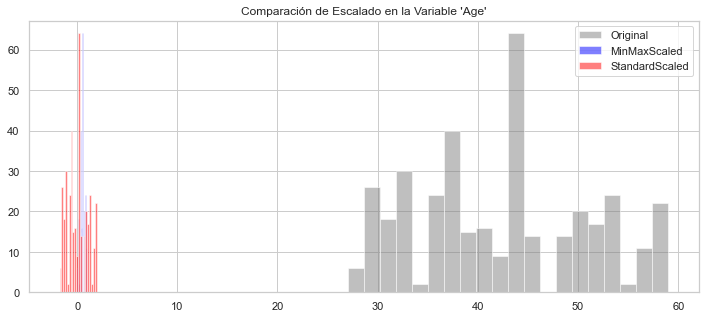

----- Datos Originales -----
              Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
count  374.000000      374.000000        374.000000               374.000000   
mean    42.184492        7.132086          7.312834                59.171123   
std      8.673133        0.795657          1.196956                20.830804   
min     27.000000        5.800000          4.000000                30.000000   
25%     35.250000        6.400000          6.000000                45.000000   
50%     43.000000        7.200000          7.000000                60.000000   
75%     50.000000        7.800000          8.000000                75.000000   
max     59.000000        8.500000          9.000000                90.000000   

       Stress Level  Heart Rate   Daily Steps  Systolic BP  Diastolic BP  
count    374.000000  374.000000    374.000000   374.000000    374.000000  
mean       5.385027   70.165775   6816.844920   128.553476     84.649733  
std        1.774526    4.

In [60]:
from sklearn.preprocessing import MinMaxScaler
# Seleccionar solo las columnas numéricas a escalar
columnas_numericas = ["Age", "Sleep Duration", "Quality of Sleep", "Physical Activity Level", 
                       "Stress Level", "Heart Rate", "Daily Steps", "Systolic BP", "Diastolic BP"]

# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[columnas_numericas] = minmax_scaler.fit_transform(df[columnas_numericas])

# Aplicar StandardScaler
standard_scaler = StandardScaler()
df_standard = df.copy()
df_standard[columnas_numericas] = standard_scaler.fit_transform(df[columnas_numericas])

# Comparar histogramas de una variable (ejemplo: 'Age')
plt.figure(figsize=(12,5))
plt.hist(df[columnas_numericas]["Age"], bins=20, alpha=0.5, label="Original", color="gray")
plt.hist(df_minmax[columnas_numericas]["Age"], bins=20, alpha=0.5, label="MinMaxScaled", color="blue")
plt.hist(df_standard[columnas_numericas]["Age"], bins=20, alpha=0.5, label="StandardScaled", color="red")
plt.legend()
plt.title("Comparación de Escalado en la Variable 'Age'")
plt.show()

# Mostrar estadísticas básicas
print("----- Datos Originales -----")
print(df[columnas_numericas].describe())

print("\n----- MinMaxScaler -----")
print(df_minmax[columnas_numericas].describe())

print("\n----- StandardScaler -----")
print(df_standard[columnas_numericas].describe())

Utilizamos MinMaxScaler porque tenemos diferentes escalas (edad en años, presión arterial en mmHg)

Además el otro nos da números negativos y luego no podemos trabajar con ellos

In [61]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
            'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# vemos el resultado
df.head()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Systolic BP,Diastolic BP
0,1,0.00000,0.111111,0.4,0.2,0.6,2,0.571429,0.171429,None,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.407407,0.40
1,2,0.03125,0.148148,0.4,0.5,1.0,1,0.476190,1.000000,None,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.370370,0.25
2,3,0.03125,0.148148,0.4,0.5,1.0,1,0.476190,1.000000,None,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.370370,0.25
3,4,0.03125,0.037037,0.0,0.0,1.0,3,0.952381,0.000000,Sleep Apnea,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.925926,0.75
4,5,0.03125,0.037037,0.0,0.0,1.0,3,0.952381,0.000000,Sleep Apnea,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.925926,0.75


## 4. ANÁLISIS DE CORRELACIONES

Ver si las correlaciones son de tipo lineal o no.

<ipython-input-62-b1461fdf490c>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")


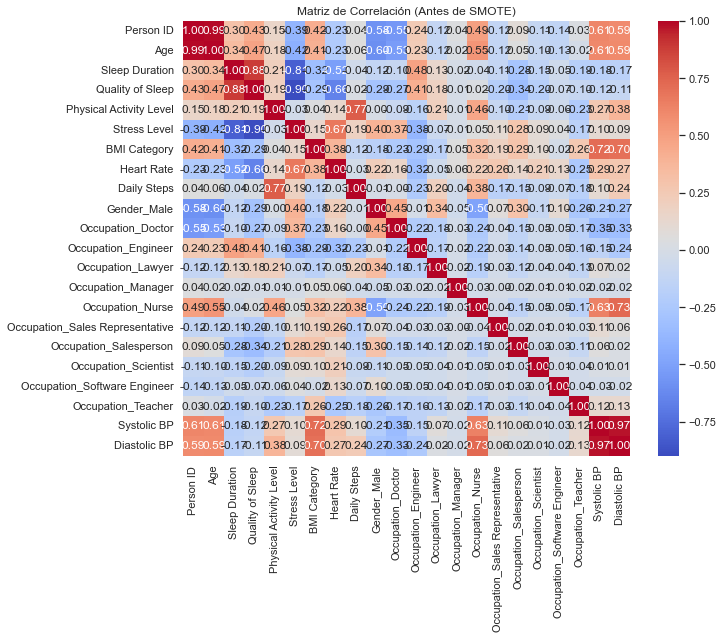

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación (Antes de SMOTE)")
plt.show()

<ipython-input-63-d4af45c16b2b>:6: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)


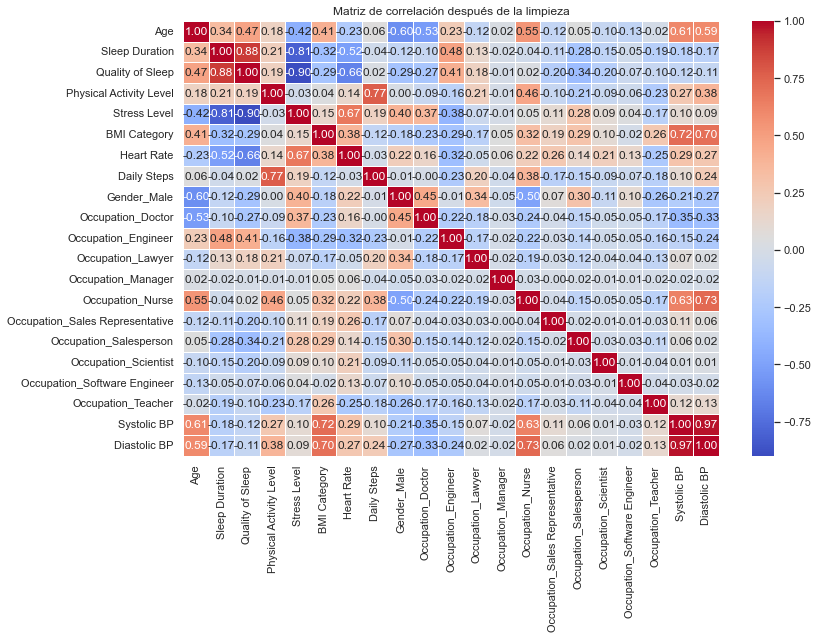

In [63]:
# Eliminamos las variables con alta correlación
df = df.drop(columns=['Person ID']) 

# Volvemos a graficar la matriz de correlación
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación después de la limpieza")
plt.show()


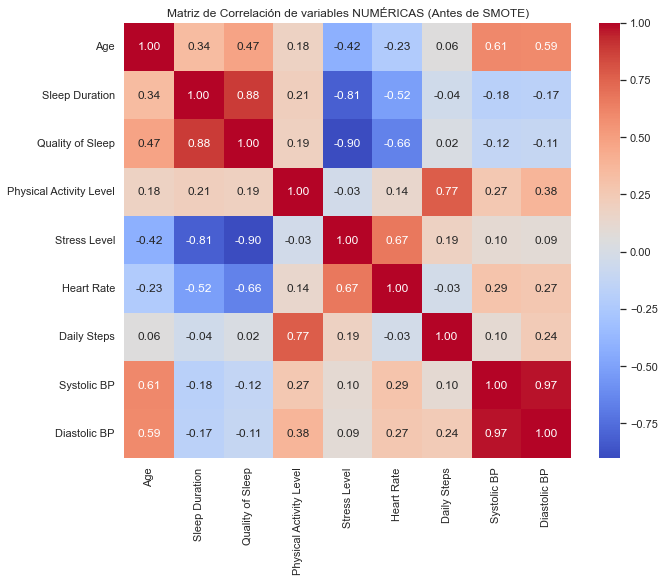

In [64]:
## VARIABLES NUMÉRICAS
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación de variables NUMÉRICAS (Antes de SMOTE)")
plt.show()

## 5. SELECCIÓN DE CARACTERÍSTICAS

In [65]:
# Ver valores nulos en el dataset
print("\nValores nulos en cada columna:")
print(df.isnull().sum())


Valores nulos en cada columna:
Age                                0
Sleep Duration                     0
Quality of Sleep                   0
Physical Activity Level            0
Stress Level                       0
BMI Category                       0
Heart Rate                         0
Daily Steps                        0
Sleep Disorder                     0
Gender_Male                        0
Occupation_Doctor                  0
Occupation_Engineer                0
Occupation_Lawyer                  0
Occupation_Manager                 0
Occupation_Nurse                   0
Occupation_Sales Representative    0
Occupation_Salesperson             0
Occupation_Scientist               0
Occupation_Software Engineer       0
Occupation_Teacher                 0
Systolic BP                        0
Diastolic BP                       0
dtype: int64


B) FEATURE IMPORTANCE CON RANDOM FOREST

Evalúa la importancia de cada variable basándose en cómo afectan a la predicción

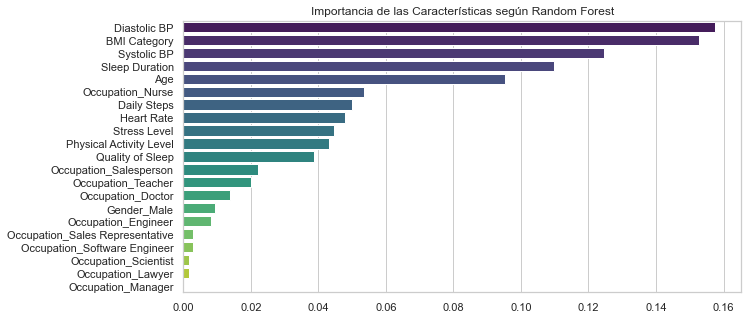

In [66]:
# PRUEBA!!! IMPORTANCIA CARACTERISTICAS
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# Separar características y variable objetivo
X = df.drop(columns=['Sleep Disorder'])  # Quitamos ID y target
y = df['Sleep Disorder']

# Entrenar modelo de Random Forest para ver importancia de variables
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Obtener importancia de características
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Visualizar la importancia de las variables
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title("Importancia de las Características según Random Forest")
plt.show()


Diastolic BP                       0.157398
BMI Category                       0.152669
Systolic BP                        0.124486
Sleep Duration                     0.109786
Age                                0.095251
Occupation_Nurse                   0.053418
Daily Steps                        0.049910
Heart Rate                         0.048011
Stress Level                       0.044551
Physical Activity Level            0.043058
Quality of Sleep                   0.038797
Occupation_Salesperson             0.022109
Occupation_Teacher                 0.020015
Occupation_Doctor                  0.013786
Gender_Male                        0.009487
Occupation_Engineer                0.008170
Occupation_Sales Representative    0.002878
Occupation_Software Engineer       0.002754
Occupation_Scientist               0.001788
Occupation_Lawyer                  0.001676
Occupation_Manager                 0.000000
dtype: float64


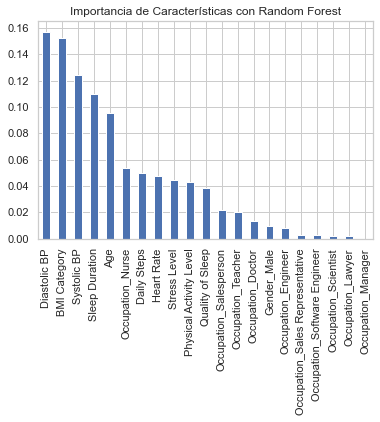

In [67]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Separar variables predictoras y objetivo
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder']

# Entrenar Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Importancia de características
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Mostrar las más importantes
print(importances)

# Graficar importancia de características
importances.plot(kind='bar', title="Importancia de Características con Random Forest")
plt.show()


C) SELECCIÓN SELECTKBEST con chi2

In [68]:
from sklearn.feature_selection import chi2, SelectKBest

# Asegurar que todas las variables sean numéricas
X = df.drop(columns=['Sleep Disorder'])
y = df['Sleep Disorder'].astype('category').cat.codes  # Convertimos temporalmente a numérico

# Aplicar prueba de chi2
selector = SelectKBest(chi2, k='all')  # Evaluamos todas las características
X_new = selector.fit_transform(X, y)

# Mostrar los valores de chi2
chi2_scores = selector.scores_
feature_names = X.columns

# Crear un DataFrame con los resultados
chi2_results = pd.DataFrame({'Feature': feature_names, 'Chi2 Score': chi2_scores})
chi2_results = chi2_results.sort_values(by='Chi2 Score', ascending=False)

# Mostrar las características ordenadas por importancia
print(chi2_results)


                            Feature  Chi2 Score
13                 Occupation_Nurse  173.900836
15           Occupation_Salesperson   96.015096
5                      BMI Category   55.986535
18               Occupation_Teacher   53.897596
20                     Diastolic BP   43.368515
19                      Systolic BP   32.819674
9                 Occupation_Doctor   29.217291
10              Occupation_Engineer   27.075301
8                       Gender_Male   26.862604
11                Occupation_Lawyer   18.427140
3           Physical Activity Level   17.778100
0                               Age   13.828096
1                    Sleep Duration    9.637225
6                        Heart Rate    8.870234
14  Occupation_Sales Representative    7.589744
7                       Daily Steps    4.305998
2                  Quality of Sleep    4.178586
4                      Stress Level    3.385740
16             Occupation_Scientist    2.502634
17     Occupation_Software Engineer    1

- Un **Chi2 Score alto** indica una mayor relación con *Sleep Disorder*
- Las variables más influyentes son:
    - Occupation_Nurse (173.9)
    - Occupation_Salesperson (96.0)
    - BMI Category (55.9)
    - Occupation_Teacher (53.8)
    - Diastolic BP (43.3)

Esto sugiere que la **ocupación** y el **BMI Category** tienen una fuerte relación con el trastorno del sueño

D) SELECCIÓN RECURSIVA DE CARACTERÍSTICAS (RFE)

Utiliza un modelo para ir eliminando las características menos relevantes de manera iterativa.

In [69]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Modelo base (puede ser otro)
model = LogisticRegression(max_iter=1000)

# Aplicar RFE para seleccionar las 5 mejores características
selector = RFE(model, n_features_to_select=5, step=1)
selector = selector.fit(X, y)

# Variables seleccionadas
selected_features = X.columns[selector.support_]
print("Características seleccionadas con RFE:", selected_features)


Características seleccionadas con RFE: Index(['Age', 'Sleep Duration', 'Heart Rate', 'Occupation_Nurse',
       'Diastolic BP'],
      dtype='object')


SELECCIÓN BASADA EN MÉTODOS ESTADÍSTICOS

Si *Sleep Disorder* es categórica, usamos **chi-cuadrado**; si es numérica, usamos **ANOVA**.

In [70]:
X.describe()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Gender_Male,Occupation_Doctor,...,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,Systolic BP,Diastolic BP
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,...,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,0.474515,0.493365,0.662567,0.486185,0.477005,1.393048,0.245989,0.545264,0.505348,0.189840,...,0.125668,0.002674,0.195187,0.005348,0.085561,0.010695,0.010695,0.106952,0.501981,0.482487
std,0.271035,0.294688,0.239391,0.347180,0.354905,0.636727,0.196937,0.231131,0.500641,0.392699,...,0.331919,0.051709,0.396876,0.073029,0.280090,0.103001,0.103001,0.309466,0.286967,0.308081
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.257812,0.222222,0.400000,0.250000,0.200000,1.000000,0.142857,0.371429,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.370370,0.250000
50%,0.500000,0.518519,0.600000,0.500000,0.400000,1.000000,0.238095,0.571429,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.555556,0.500000
75%,0.718750,0.740741,0.800000,0.750000,0.800000,2.000000,0.333333,0.714286,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.740741,0.750000
max,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [71]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Para variable categórica (Chi-cuadrado)
chi2_selector = SelectKBest(score_func=chi2, k=5)
chi2_selector.fit(X, y)

# Para variable numérica (ANOVA)
anova_selector = SelectKBest(score_func=f_classif, k=5)
anova_selector.fit(X, y)

# Mostrar resultados
print("Características seleccionadas con Chi-cuadrado:", X.columns[chi2_selector.get_support()])
print("Características seleccionadas con ANOVA:", X.columns[anova_selector.get_support()])


Características seleccionadas con Chi-cuadrado: Index(['BMI Category', 'Occupation_Nurse', 'Occupation_Salesperson',
       'Occupation_Teacher', 'Diastolic BP'],
      dtype='object')
Características seleccionadas con ANOVA: Index(['BMI Category', 'Occupation_Nurse', 'Occupation_Salesperson',
       'Systolic BP', 'Diastolic BP'],
      dtype='object')


### SMOTE (estudio de la posibilidad de su uso)

In [72]:
X = df.drop(columns=['Sleep Disorder'])  # Sleep Disorder es la variable objetivo
y = df['Sleep Disorder']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
df_balanced = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.DataFrame(y_resampled, columns=['Sleep Disorder'])], axis=1)

ANÁLISIS DE DATOS DESBALANCEADOS

In [73]:
# Distribución de clases antes de SMOTE
print(df['Sleep Disorder'].value_counts(normalize=True) * 100)

None           58.556150
Sleep Apnea    20.855615
Insomnia       20.588235
Name: Sleep Disorder, dtype: float64


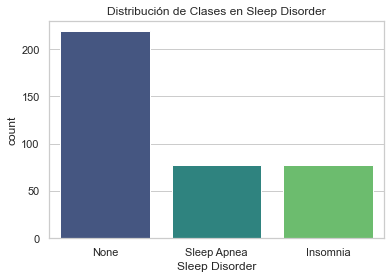

In [74]:
sns.countplot(x=y, palette="viridis")  # 'y' es la variable objetivo
plt.title("Distribución de Clases en Sleep Disorder")
plt.show()

In [75]:
# DESPUES DE SMOTE CONTAMOS CLASES
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Ver distribución después de SMOTE
print(pd.Series(y_resampled).value_counts(normalize=True) * 100)

None           33.333333
Sleep Apnea    33.333333
Insomnia       33.333333
Name: Sleep Disorder, dtype: float64


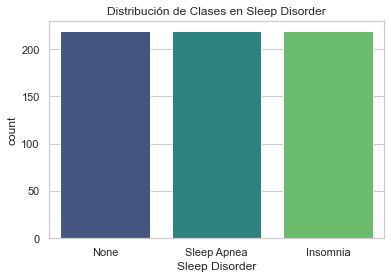

In [76]:
sns.countplot(x=y_resampled, palette="viridis")  # 'y' es la variable objetivo
plt.title("Distribución de Clases en Sleep Disorder")
plt.show()

## 6. MODELOS PREDICTIVOS

### DIVIDIMOS LOS DATOS EN ENTRENAMIENTO Y PRUEBA

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


### EVALUACIÓN DE MODELOS PREDICTIVOS

Modelo: Logistic Regression

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       0.98      0.95      0.97        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.93        75
   macro avg       0.91      0.92      0.91        75
weighted avg       0.94      0.93      0.93        75

Matriz de confusión:


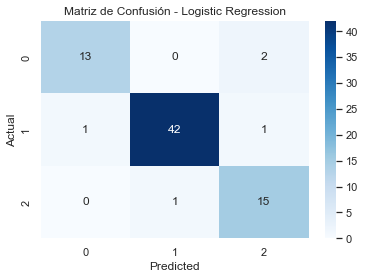



Modelo: Decision Tree

              precision    recall  f1-score   support

    Insomnia       0.88      0.93      0.90        15
        None       1.00      0.95      0.98        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.95        75
   macro avg       0.92      0.94      0.93        75
weighted avg       0.95      0.95      0.95        75

Matriz de confusión:


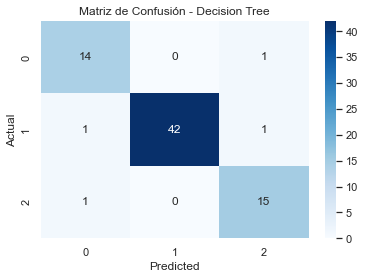



Modelo: SVM

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       0.93      0.95      0.94        44
 Sleep Apnea       0.88      0.88      0.88        16

    accuracy                           0.92        75
   macro avg       0.91      0.90      0.91        75
weighted avg       0.92      0.92      0.92        75

Matriz de confusión:


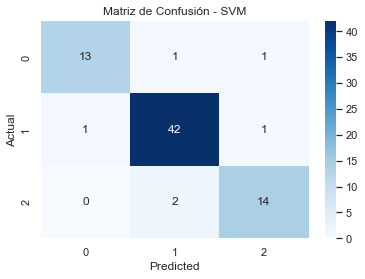



Modelo: MLP

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75

Matriz de confusión:


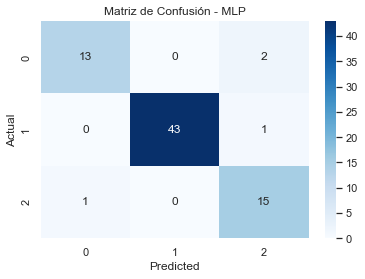



Modelo: Random Forest

              precision    recall  f1-score   support

    Insomnia       0.87      0.87      0.87        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75

Matriz de confusión:


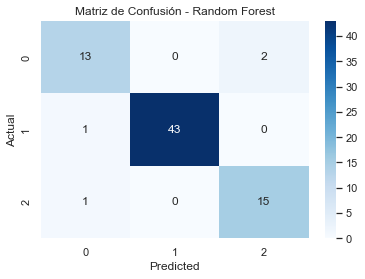

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Diccionario de modelos a evaluar
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True),
    "MLP": MLPClassifier(max_iter=1000),
    "Random Forest": RandomForestClassifier()
}

# Entrenar y evaluar cada modelo
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)  # Entrenamiento
    y_pred = model.predict(X_test)  # Predicción
    
    # Guardar resultados
    results[name] = {
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }
    
    # Mostrar resultados
    print(f"Modelo: {name}\n")
    print(classification_report(y_test, y_pred))
    print("Matriz de confusión:")
    sns.heatmap(results[name]["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusión - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    print("\n" + "="*50 + "\n")


Tras la implementación de varios modelos, se han evaluacdo las métricas básicas para escoger los mejores y llevar a cabo la optimización de hiperparámetros.

### COMPARACIÓN DE MODELOS CON Y SIN SMOTE

In [79]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


Distribución original: Counter({'None': 175, 'Sleep Apnea': 62, 'Insomnia': 62})
Distribución después de SMOTE: Counter({'None': 175, 'Sleep Apnea': 175, 'Insomnia': 175})
Modelo: Logistic Regression (con SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      0.93      0.96        44
 Sleep Apnea       0.80      1.00      0.89        16

    accuracy                           0.93        75
   macro avg       0.91      0.93      0.92        75
weighted avg       0.94      0.93      0.93        75

Matriz de confusión:


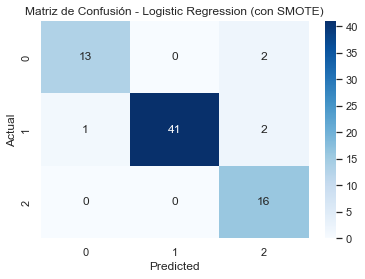



Modelo: Decision Tree (con SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.81      0.87      0.84        15
        None       1.00      0.95      0.98        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.93        75
   macro avg       0.90      0.92      0.91        75
weighted avg       0.94      0.93      0.93        75

Matriz de confusión:


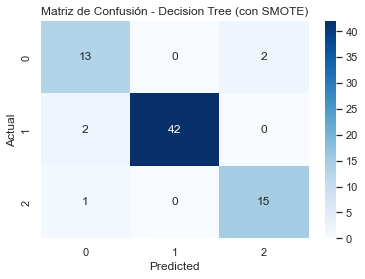



Modelo: SVM (con SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.92      0.80      0.86        15
        None       1.00      0.93      0.96        44
 Sleep Apnea       0.76      1.00      0.86        16

    accuracy                           0.92        75
   macro avg       0.89      0.91      0.90        75
weighted avg       0.93      0.92      0.92        75

Matriz de confusión:


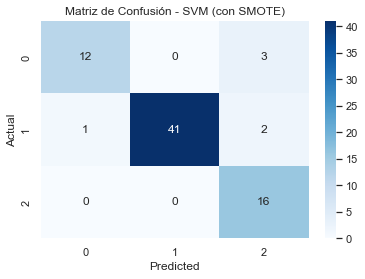



Modelo: MLP (con SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       0.96      0.98      0.97        44
 Sleep Apnea       0.81      0.81      0.81        16

    accuracy                           0.92        75
   macro avg       0.90      0.89      0.89        75
weighted avg       0.92      0.92      0.92        75

Matriz de confusión:


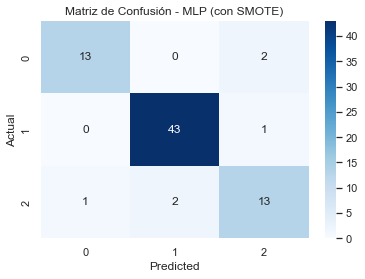



Modelo: Random Forest (con SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.76      0.87      0.81        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.92        75
   macro avg       0.88      0.89      0.88        75
weighted avg       0.92      0.92      0.92        75

Matriz de confusión:


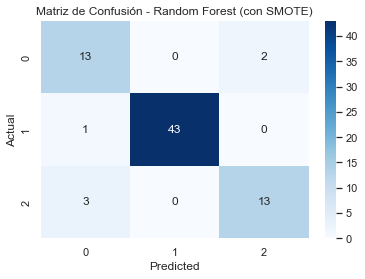

In [80]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Aplicamos SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Ver la nueva distribución de clases
print("Distribución original:", Counter(y_train))
print("Distribución después de SMOTE:", Counter(y_train_smote))

# Diccionario de modelos
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(probability=True),
    "MLP": MLPClassifier(max_iter=1000),
    "Random Forest": RandomForestClassifier()
}

# Entrenar y evaluar cada modelo con SMOTE
results_smote = {}
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)  # Entrenamiento con datos balanceados
    y_pred_smote = model.predict(X_test)  # Predicción
    
    # Guardar resultados
    results_smote[name] = {
        "classification_report": classification_report(y_test, y_pred_smote, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred_smote)
    }
    
    # Mostrar resultados
    print(f"Modelo: {name} (con SMOTE)\n")
    print(classification_report(y_test, y_pred_smote))
    print("Matriz de confusión:")
    sns.heatmap(results_smote[name]["confusion_matrix"], annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de Confusión - {name} (con SMOTE)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    print("\n" + "="*50 + "\n")


Distribución sin SMOTE: Counter({'None': 175, 'Sleep Apnea': 62, 'Insomnia': 62})
Modelo: Logistic Regression (sin SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       0.98      0.95      0.97        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.93        75
   macro avg       0.91      0.92      0.91        75
weighted avg       0.94      0.93      0.93        75

Matriz de confusión:


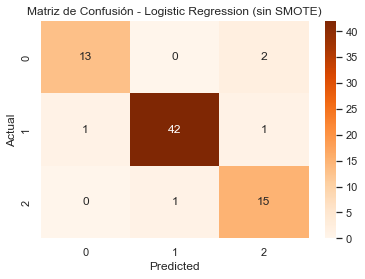



Modelo: Decision Tree (sin SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.76      0.87      0.81        15
        None       1.00      0.95      0.98        44
 Sleep Apnea       0.81      0.81      0.81        16

    accuracy                           0.91        75
   macro avg       0.86      0.88      0.87        75
weighted avg       0.91      0.91      0.91        75

Matriz de confusión:


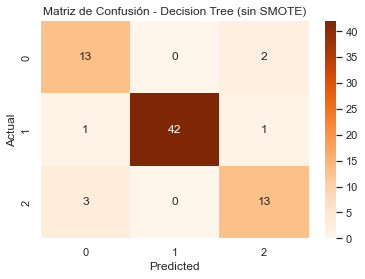



Modelo: SVM (sin SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       0.93      0.95      0.94        44
 Sleep Apnea       0.88      0.88      0.88        16

    accuracy                           0.92        75
   macro avg       0.91      0.90      0.91        75
weighted avg       0.92      0.92      0.92        75

Matriz de confusión:


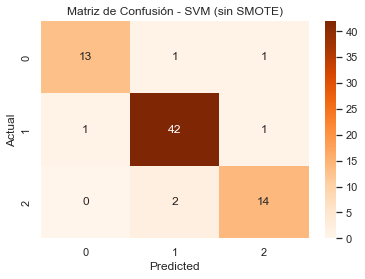



Modelo: MLP (sin SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.82      0.93      0.87        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.87      0.81      0.84        16

    accuracy                           0.93        75
   macro avg       0.90      0.91      0.90        75
weighted avg       0.94      0.93      0.93        75

Matriz de confusión:


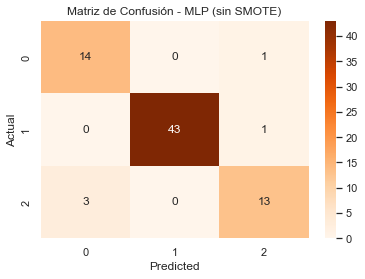



Modelo: Random Forest (sin SMOTE)

              precision    recall  f1-score   support

    Insomnia       0.87      0.87      0.87        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75

Matriz de confusión:


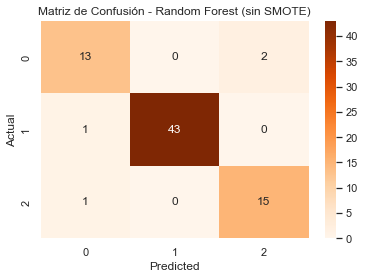

In [81]:
# Entrenamiento de modelos SIN SMOTE
results_no_smote = {}

print("Distribución sin SMOTE:", Counter(y_train))

for name, model in models.items():
    model.fit(X_train, y_train)  # Entrenamiento SIN balancear
    y_pred = model.predict(X_test)

    results_no_smote[name] = {
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

    # Mostrar resultados
    print(f"Modelo: {name} (sin SMOTE)\n")
    print(classification_report(y_test, y_pred))
    print("Matriz de confusión:")
    sns.heatmap(results_no_smote[name]["confusion_matrix"], annot=True, fmt="d", cmap="Oranges")
    plt.title(f"Matriz de Confusión - {name} (sin SMOTE)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    print("\n" + "="*50 + "\n")


In [82]:
import pandas as pd

modelos = ["Logistic Regression", "Decision Tree", "SVM", "MLP", "Random Forest"]

# Crear lista de diccionarios con las métricas seleccionadas
comparativa = []

for modelo in modelos:
    report_smote = results_smote[modelo]["classification_report"]
    report_no_smote = results_no_smote[modelo]["classification_report"]

    fila = {
        "Modelo": modelo,
        "Accuracy (SMOTE)": report_smote["accuracy"],
        "Accuracy (No SMOTE)": report_no_smote["accuracy"],
        "F1 Macro (SMOTE)": report_smote["macro avg"]["f1-score"],
        "F1 Macro (No SMOTE)": report_no_smote["macro avg"]["f1-score"],
        "Recall Apnea (SMOTE)": report_smote["Sleep Apnea"]["recall"],
        "Recall Apnea (No SMOTE)": report_no_smote["Sleep Apnea"]["recall"],
        "Precision Apnea (SMOTE)": report_smote["Sleep Apnea"]["precision"],
        "Precision Apnea (No SMOTE)": report_no_smote["Sleep Apnea"]["precision"],
        "Recall Insomnia (SMOTE)": report_smote["Insomnia"]["recall"],
        "Recall Insomnia (No SMOTE)": report_no_smote["Insomnia"]["recall"],
        "Precision Insomnia (SMOTE)": report_smote["Insomnia"]["precision"],
        "Precision Insomnia (No SMOTE)": report_no_smote["Insomnia"]["precision"],
    }

    comparativa.append(fila)

# Convertir en DataFrame y mostrar
df_comparativa = pd.DataFrame(comparativa)
pd.set_option("display.max_columns", None)  # Mostrar todas las columnas
display(df_comparativa)


,Modelo,Accuracy (SMOTE),Accuracy (No SMOTE),F1 Macro (SMOTE),F1 Macro (No SMOTE),Recall Apnea (SMOTE),Recall Apnea (No SMOTE),Precision Apnea (SMOTE),Precision Apnea (No SMOTE),Recall Insomnia (SMOTE),Recall Insomnia (No SMOTE),Precision Insomnia (SMOTE),Precision Insomnia (No SMOTE)
0,Logistic Regression,0.933333,0.933333,0.916715,0.914807,1.0000,0.9375,0.800000,0.833333,0.866667,0.866667,0.928571,0.928571
1,Decision Tree,0.933333,0.906667,0.908182,0.867248,0.9375,0.8125,0.882353,0.812500,0.866667,0.866667,0.812500,0.764706
2,SVM,0.920000,0.920000,0.895571,0.905124,1.0000,0.8750,0.761905,0.875000,0.800000,0.866667,0.923077,0.928571
3,MLP,0.920000,0.933333,0.891781,0.900738,0.8125,0.8125,0.812500,0.866667,0.866667,0.933333,0.928571,0.823529
4,Random Forest,0.920000,0.946667,0.879905,0.921421,0.8125,0.9375,0.866667,0.882353,0.866667,0.866667,0.764706,0.866667


Dado que los resultados con y sin SMOTE son muy similares en todas las métricas clave (accuracy, F1 macro y recall por clase), se optó por usar el modelo sin SMOTE para reflejar un escenario clínico más realista

### AJUSTE DE HIPERPARÁMETROS

1) RANDOM FOREST

Parámtros a ajustar:
- n_estimators
- max_depth
- min_samples_split, min_samples_leaf

In [83]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Definir el modelo
rf = RandomForestClassifier(random_state=42)

# Definir el espacio de búsqueda de hiperparámetros
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Configurar la búsqueda aleatoria
rf_random = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_dist, 
    n_iter=20,  # Número de combinaciones a probar
    cv=5,  # Validación cruzada
    verbose=2, 
    random_state=42, 
    n_jobs=-1
)

# Ajustar el modelo a los datos de entrenamiento (X_train, y_train deben estar definidos)
rf_random.fit(X_train, y_train)

# Mejor combinación de hiperparámetros encontrada
print("Mejores hiperparámetros para Random Forest:", rf_random.best_params_)

# Evaluación en los datos de prueba (X_test, y_test deben estar definidos)
y_pred = rf_random.best_estimator_.predict(X_test)

from sklearn.metrics import classification_report
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros para Random Forest: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}
Reporte de clasificación:
               precision    recall  f1-score   support

    Insomnia       0.93      0.93      0.93        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.97        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.97      0.97      0.97        75



In [84]:
import joblib
joblib.dump(rf_random.best_estimator_, 'random_forest_model.joblib')


['random_forest_model.joblib']

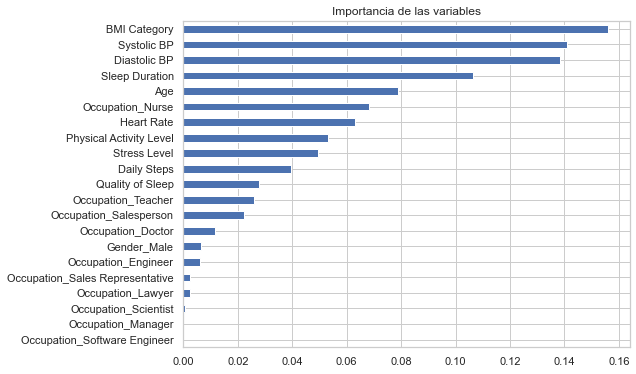

In [85]:
importances = pd.Series(rf_random.best_estimator_.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,6), title='Importancia de las variables')
plt.show()


2) DECISION TREE

Parámetros a ajustar:
- max_depth
- min_samples_split
- min_samples_leaf
- criterion

In [86]:
from sklearn.model_selection import GridSearchCV
# Definir el modelo Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Definir el espacio de búsqueda de hiperparámetros para Decision Tree
param_grid_dt = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Configurar la búsqueda de cuadrícula para Decision Tree
dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Ajustar el modelo a los datos de entrenamiento
dt_grid.fit(X_train, y_train)

# Mejor combinación de hiperparámetros encontrada para Decision Tree
print("Mejores hiperparámetros para Decision Tree:", dt_grid.best_params_)

# Evaluación en los datos de prueba para Decision Tree
dt_y_pred = dt_grid.best_estimator_.predict(X_test)
print("Reporte de clasificación para Decision Tree:\n", classification_report(y_test, dt_y_pred))


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Mejores hiperparámetros para Decision Tree: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Reporte de clasificación para Decision Tree:
               precision    recall  f1-score   support

    Insomnia       1.00      0.80      0.89        15
        None       0.96      0.98      0.97        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.93        75
   macro avg       0.93      0.90      0.91        75
weighted avg       0.94      0.93      0.93        75



In [87]:
import joblib
joblib.dump(dt_grid.best_estimator_, "decision_tree_model.joblib")

['decision_tree_model.joblib']

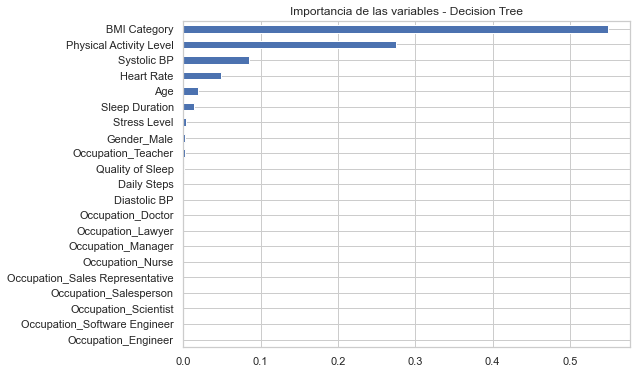

In [88]:
importances = pd.Series(dt_grid.best_estimator_.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,6), title='Importancia de las variables - Decision Tree')
plt.show()

3) MLP 

Parámtros a ajustar:

- hidden_layer_sizes
- activation
- alpha
- learning_rate_init 
- solver

In [89]:
# Definir el modelo MLP
mlp = MLPClassifier(max_iter=1000, random_state=42)

# Definir el espacio de búsqueda de hiperparámetros para MLP
param_dist_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50,50), (100,50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

# Configurar la búsqueda aleatoria para MLP
mlp_random = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist_mlp,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Ajustar el modelo a los datos de entrenamiento
mlp_random.fit(X_train, y_train)

# Mejor combinación de hiperparámetros encontrada para MLP
print("Mejores hiperparámetros para MLP:", mlp_random.best_params_)

# Evaluación en los datos de prueba para MLP
mlp_y_pred = mlp_random.best_estimator_.predict(X_test)
print("Reporte de clasificación para MLP:\n", classification_report(y_test, mlp_y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros para MLP: {'solver': 'adam', 'learning_rate': 'constant', 'hidden_layer_sizes': (50,), 'alpha': 0.01, 'activation': 'tanh'}
Reporte de clasificación para MLP:
               precision    recall  f1-score   support

    Insomnia       1.00      0.93      0.97        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.89      1.00      0.94        16

    accuracy                           0.97        75
   macro avg       0.96      0.97      0.97        75
weighted avg       0.98      0.97      0.97        75



In [90]:
import joblib
joblib.dump(mlp_random.best_estimator_, "mlp_model.joblib")

['mlp_model.joblib']

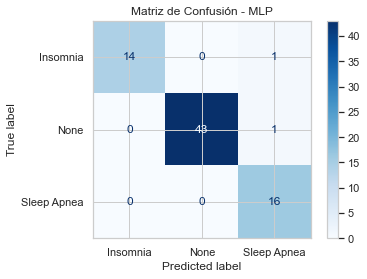

In [91]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(mlp_random.best_estimator_, X_test, y_test, cmap="Blues")
plt.title("Matriz de Confusión - MLP")
plt.show()

4) LOGISTIC REGRESSION

Parámtros a ajustar:
- penalty(tipo de regularización: l1 (Lasso), l2 (Ridge)
- c (regularización)
- solver (método de optimización)

In [92]:
# Definir el modelo Logist Regression
log_reg = LogisticRegression(max_iter=5000)

# Definir la cuadrícula de hiperparámetros
param_grid = {
    'penalty': ['l1', 'l2'],
    'C':  [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
}

# Realizar la búsqueda con validación cruzada
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros y evaluar en el test set
print("Mejores hiperparámetros para Logistic Regression:", grid_search.best_params_)

# Evaluación en test set
best_log_reg = grid_search.best_estimator_
y_pred = best_log_reg.predict(X_test)
print("Reporte de clasificación para Logistic Regression:\n", classification_report(y_test, y_pred))

Mejores hiperparámetros para Logistic Regression: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Reporte de clasificación para Logistic Regression:
               precision    recall  f1-score   support

    Insomnia       0.93      0.93      0.93        15
        None       1.00      0.95      0.98        44
 Sleep Apnea       0.89      1.00      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.96      0.95        75
weighted avg       0.96      0.96      0.96        75



In [93]:
import joblib
joblib.dump(best_log_reg, "logistic_regression_model.joblib")

['logistic_regression_model.joblib']

In [94]:
print("Orden de clases en el modelo:", best_log_reg.classes_)

Orden de clases en el modelo: ['Insomnia' 'None' 'Sleep Apnea']


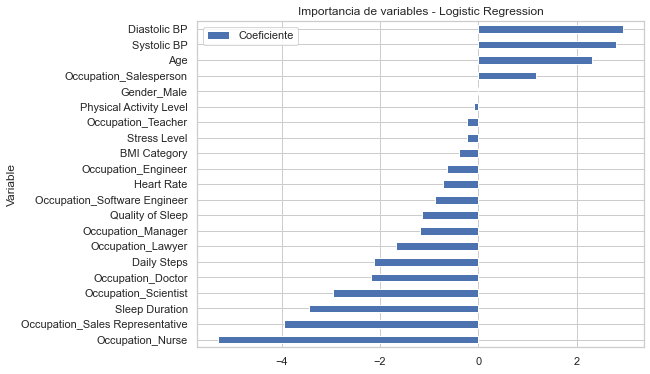

In [95]:
import numpy as np
coef_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": best_log_reg.coef_[0]
}).sort_values(by="Coeficiente")
coef_df.plot(x="Variable", y="Coeficiente", kind="barh", figsize=(8,6), title="Importancia de variables - Logistic Regression")
plt.show()

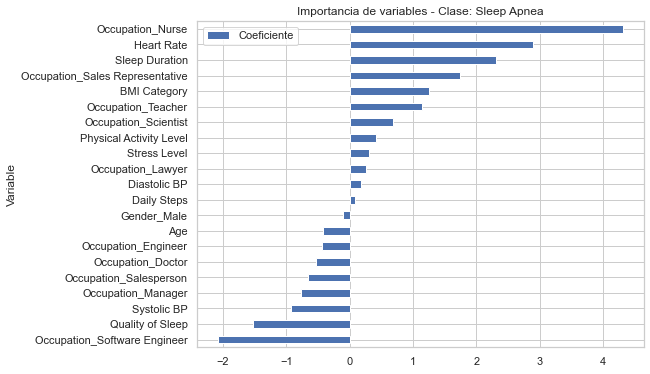

In [96]:
pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": best_log_reg.coef_[2]
}).sort_values(by="Coeficiente").plot(
    x="Variable", y="Coeficiente", kind="barh", figsize=(8,6),
    title="Importancia de variables - Clase: Sleep Apnea"
)
plt.show()

- Si el coeficiente es **positivo** (barra hacia la derecha), **aumenta la probabilidad** de que el modelo prediga la clase **Insomnio** (en el primer caso).
- Si el coeficiente es **negativo** (barra hacia la izquierda), **disminuye la probabilidad de predecir esa clase**

5) SVM

Parámetros a ajustar:
- Parámetro C (regularización)
- kernel --> tipo de kernel
- gamma --> (para kernels RBF y polinómicos)


In [97]:
# Definir el modelo SVM
svm = SVC(random_state=42)

# Definir el espacio de búsqueda de hiperparámetros para SVM
param_dist_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto']
}

# Configurar la búsqueda aleatoria para SVM
svm_random = RandomizedSearchCV(
    estimator=svm,
    param_distributions=param_dist_svm,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Ajustar el modelo a los datos de entrenamiento
svm_random.fit(X_train, y_train)

# Mejor combinación de hiperparámetros encontrada para SVM
print("Mejores hiperparámetros para SVM:", svm_random.best_params_)

# Evaluación en los datos de prueba para SVM
svm_y_pred = svm_random.best_estimator_.predict(X_test)
print("Reporte de clasificación para SVM:\n", classification_report(y_test, svm_y_pred))


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros para SVM: {'kernel': 'poly', 'gamma': 'scale', 'C': 0.1}
Reporte de clasificación para SVM:
               precision    recall  f1-score   support

    Insomnia       0.82      0.93      0.87        15
        None       0.93      0.98      0.96        44
 Sleep Apnea       1.00      0.75      0.86        16

    accuracy                           0.92        75
   macro avg       0.92      0.89      0.90        75
weighted avg       0.93      0.92      0.92        75



A pesar de que el modelo es preciso para la clase Sleep Apnea, el recall es bajo (0.75), por lo que algunos casos de apnea podrían no se detectados.

In [98]:
# Datos extraídos de los reportes anteriores
datos_modelos = [
    {
        "Modelo": "Random Forest",
        "Accuracy": 0.97,
        "F1 Macro": 0.96,
        "Recall Insomnia": 0.93,
        "Recall Apnea": 0.94,
        "Precision Apnea": 0.94,
    },
    {
        "Modelo": "Decision Tree",
        "Accuracy": 0.93,
        "F1 Macro": 0.91,
        "Recall Insomnia": 0.80,
        "Recall Apnea": 0.94,
        "Precision Apnea": 0.83,
    },
    {
        "Modelo": "MLP",
        "Accuracy": 0.97,
        "F1 Macro": 0.97,
        "Recall Insomnia": 0.93,
        "Recall Apnea": 1.00,
        "Precision Apnea": 0.89,
    },
    {
        "Modelo": "Logistic Regression",
        "Accuracy": 0.96,
        "F1 Macro": 0.95,
        "Recall Insomnia": 0.93,
        "Recall Apnea": 1.00,
        "Precision Apnea": 0.89,
    },
    {
        "Modelo": "SVM",
        "Accuracy": 0.92,
        "F1 Macro": 0.90,
        "Recall Insomnia": 0.93,
        "Recall Apnea": 0.75,
        "Precision Apnea": 1.00,
    },
]

df_modelos = pd.DataFrame(datos_modelos)
# Mostrar tabla
display(df_modelos)

,Modelo,Accuracy,F1 Macro,Recall Insomnia,Recall Apnea,Precision Apnea
0,Random Forest,0.97,0.96,0.93,0.94,0.94
1,Decision Tree,0.93,0.91,0.80,0.94,0.83
2,MLP,0.97,0.97,0.93,1.00,0.89
3,Logistic Regression,0.96,0.95,0.93,1.00,0.89
4,SVM,0.92,0.90,0.93,0.75,1.00


Para evaluar el rendimiento de los modelos predictivos desarrollados, se optó por mostrar un conjunto específico de métricas que resultan especialmente relevantes en el contexto clínico del problema. Concretamente, se incluyeron el accuracy, el F1-score macro, el recall para las clases **Insomnia** y **Sleep Apnea**, y la precisión para la clase **Sleep Apnea**.

El accuracy y el F1-score macro permiten valorar el rendimiento global del modelo, teniendo en cuenta tanto el equilibrio entre clases como la capacidad de generalización. Sin embargo, dado que el objetivo principal del proyecto es la **detección fiable de trastornos del sueño**, se consideró prioritario analizar el recall para las clases “Insomnia” y “Sleep Apnea”, ya que este indica la proporción de casos positivos correctamente identificados. Una baja sensibilidad en estas clases supondría que el modelo deja pasar sin detectar casos clínicamente relevantes.

Asimismo, se incluyó la precisión en la clase “Sleep Apnea” para complementar la interpretación: una alta precisión asegura que las personas clasificadas como afectadas por apnea del sueño tienen realmente alta probabilidad de estarlo, reduciendo así los falsos positivos que podrían generar alarmas injustificadas. La clase “None” no se priorizó explícitamente en la tabla, al tratarse del grupo sin trastorno, donde los errores de clasificación tienen menos impacto clínico directo.

### CURVA ROC-AUC Y PRECISSION-RECALL

**Curva ROC (Receiver Operating Characteristic)**

La Curva ROC es una representación gráfica que evalúa el rendimiento de un modelo de clasificación binaria al mostrar la relación entre la Tasa de Verdaderos Positivos (True Positive Rate, TPR) y la Tasa de Falsos Positivos (False Positive Rate, FPR) a través de diferentes umbrales de decisión. Cada punto en la curva corresponde a un par (FPR, TPR) para un umbral específico. El área bajo la curva ROC, conocida como AUC (Area Under the Curve), proporciona una medida única del rendimiento general del modelo; un AUC cercano a 1 indica un modelo con alta capacidad discriminativa, mientras que un AUC cercano a 0.5 sugiere un rendimiento similar al azar. ​
DataScientest

- https://www.elsevier.es/es-revista-medicina-familia-semergen-40-articulo-la-curva-roc-S1138359322001952

- https://www.datacamp.com/es/tutorial/auc


**Curva Precision-Recall**

La Curva Precision-Recall es especialmente útil en escenarios donde las clases están desbalanceadas. Esta curva grafica la Precisión frente al Recall (Sensibilidad) para diferentes umbrales de decisión. La Precisión mide la proporción de predicciones positivas que son correctas, mientras que el Recall indica la proporción de verdaderos positivos identificados correctamente por el modelo. El área bajo esta curva proporciona una medida del rendimiento del modelo en contextos de clases desbalanceadas; un área más grande indica un mejor rendimiento. 


- https://www.datacamp.com/es/tutorial/precision-recall-curve-tutorial

In [99]:
# Modelos con los mejores hiperparámetros encontrados
models = {
    "Random Forest": rf_random.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "MLP": mlp_random.best_estimator_,
    "Logistic Regression": best_log_reg,
    "SVM": svm_random.best_estimator_
}

# Lista de clases en orden específico
classes = ['Insomnia', 'None', 'Sleep Apnea']

# Binarizar etiquetas para curvas ROC y Precision-Recall
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=classes)

print("Modelos cargados con sus mejores hiperparámetros.")


Modelos cargados con sus mejores hiperparámetros.


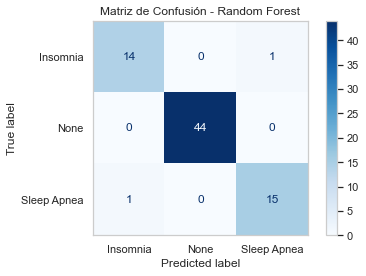

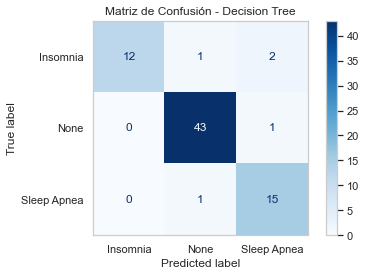

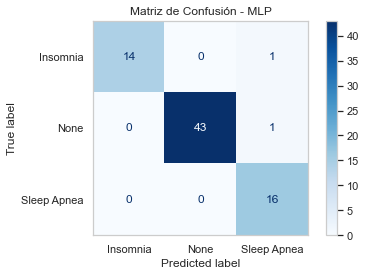

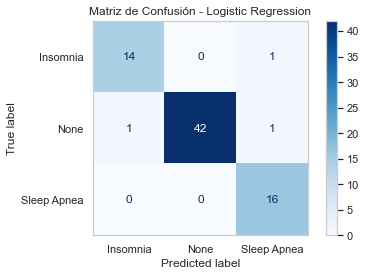

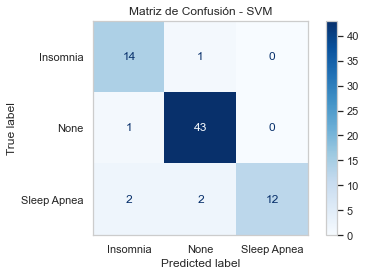

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generar y visualizar la matriz de confusión de cada modelo
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", values_format='d')
    plt.title(f"Matriz de Confusión - {name}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


CURVA ROC-AUC 

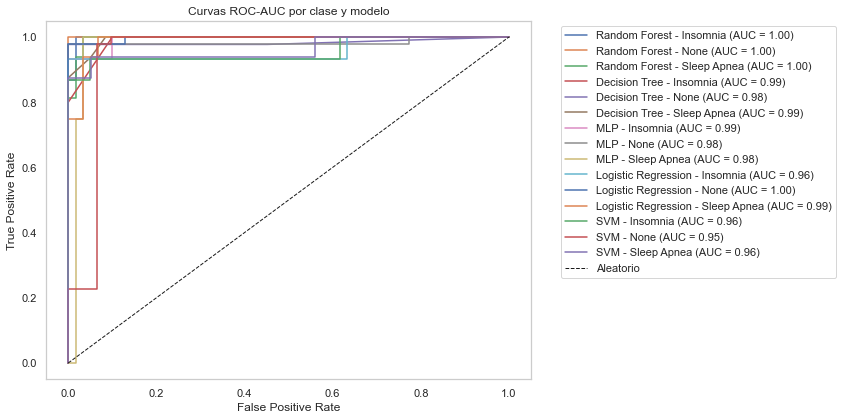

In [101]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for name, model in models.items():
    # Obtener probabilidades o scores
    y_score = model.predict_proba(X_test) if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    # Curva ROC por clase
    for i, clase in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} - {clase} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Aleatorio")
plt.title("Curvas ROC-AUC por clase y modelo")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


CURVA PRECISSION RECALL

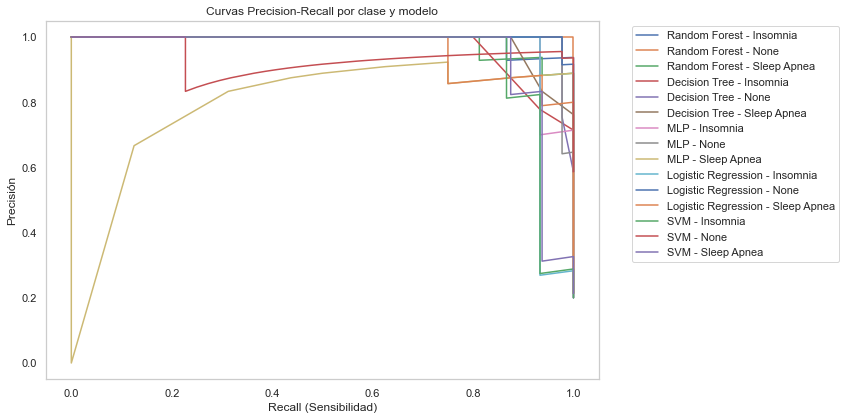

In [102]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(12, 6))

for name, model in models.items():
    # Obtener probabilidades o scores
    y_score = model.predict_proba(X_test) if hasattr(model, "predict_proba") else model.decision_function(X_test)

    # Curva Precision-Recall por clase
    for i, clase in enumerate(classes):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        plt.plot(recall, precision, label=f"{name} - {clase}")

plt.title("Curvas Precision-Recall por clase y modelo")
plt.xlabel("Recall (Sensibilidad)")
plt.ylabel("Precisión")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


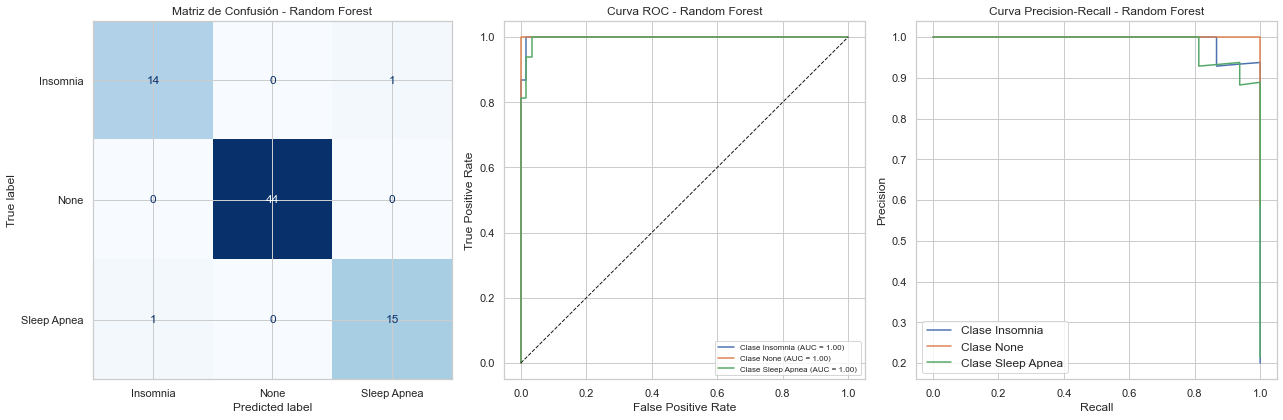

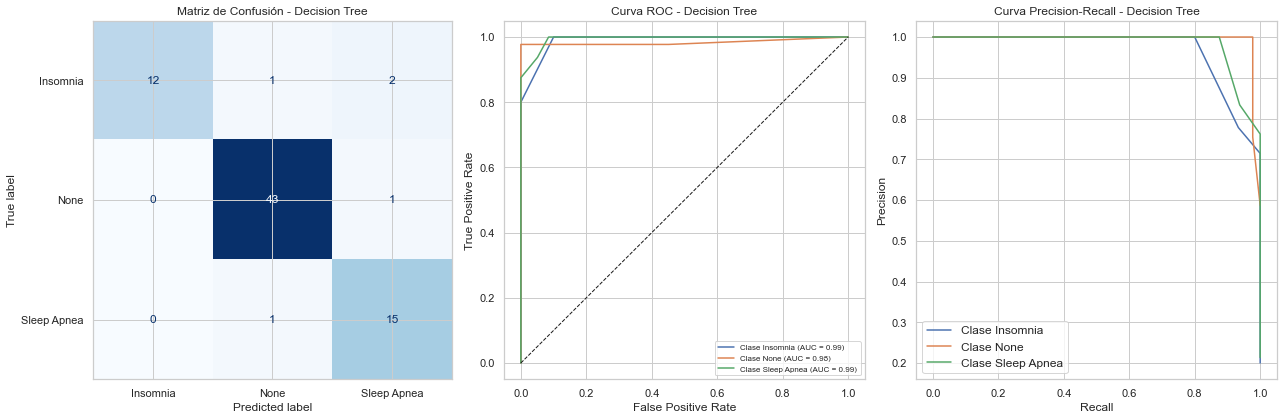

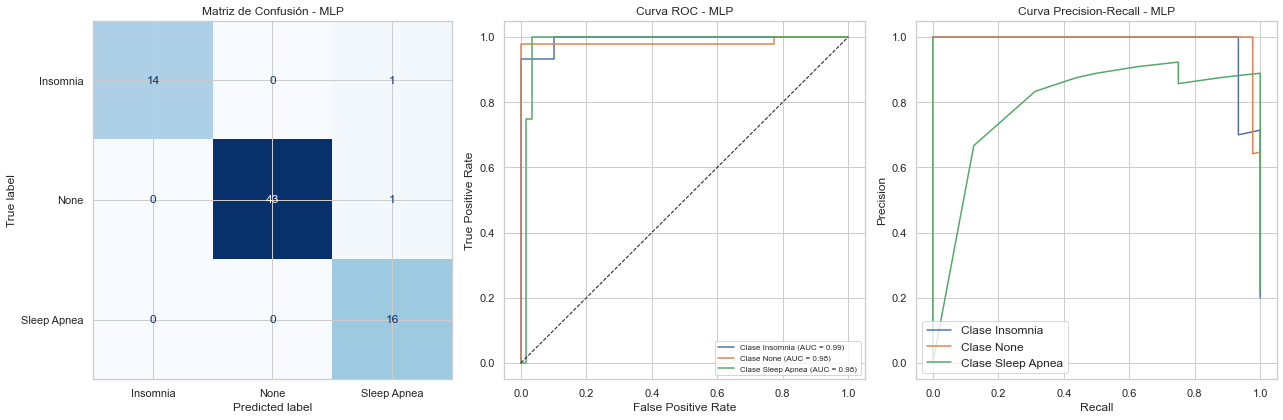

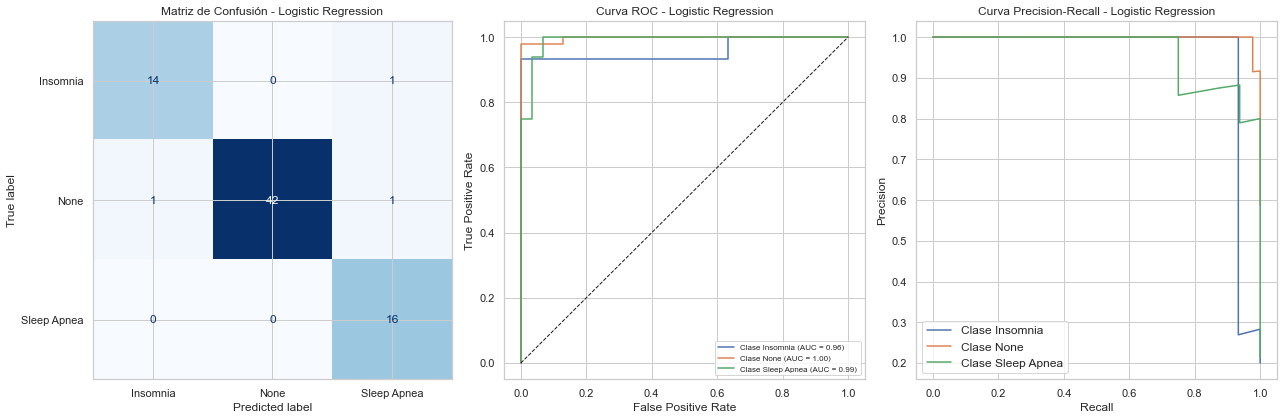

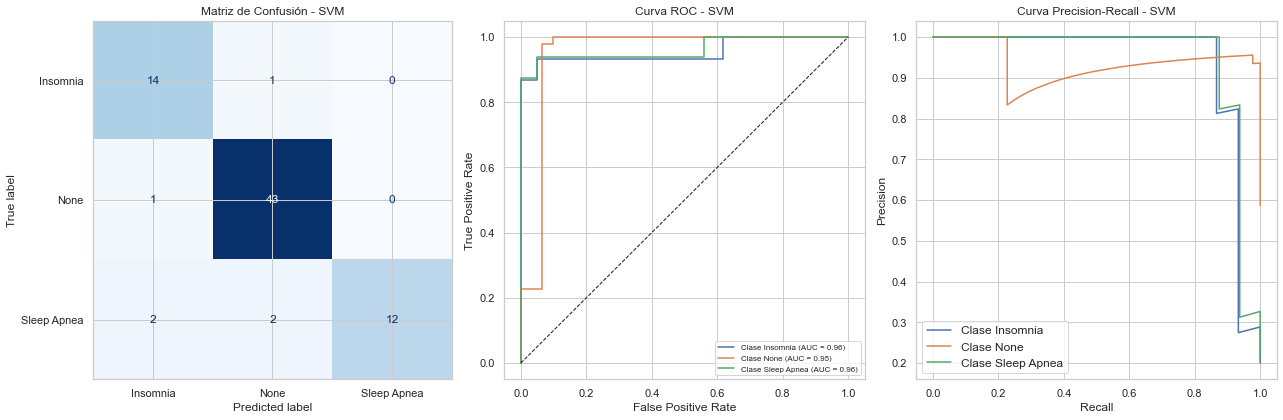

In [103]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve

# Crear una figura con 3 columnas para cada modelo
for name, model in models.items():
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))  # 1 fila, 3 columnas
    
    # --- 1. Matriz de Confusión ---
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes)
    disp.plot(ax=ax[0], cmap="Blues", colorbar=False)
    ax[0].set_title(f"Matriz de Confusión - {name}")
    
    # --- 2. Curva ROC (AUC) ---
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)
    
    # Calcular la curva ROC y AUC para cada clase
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax[1].plot(fpr, tpr, label=f"Clase {classes[i]} (AUC = {roc_auc:.2f})")
    
    ax[1].plot([0, 1], [0, 1], 'k--', linewidth=1)  # Línea diagonal (aleatorio)
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_title(f"Curva ROC - {name}")
    ax[1].legend(loc='lower right', fontsize=8)
    
    # --- 3. Curva Precision-Recall (AUPR) ---
    for i in range(len(classes)):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        ax[2].plot(recall, precision, label=f"Clase {classes[i]}")
    
    ax[2].set_xlabel('Recall')
    ax[2].set_ylabel('Precision')
    ax[2].set_title(f"Curva Precision-Recall - {name}")
    ax[2].legend(loc='lower left', fontsize=12)
    
    # Ajustar el layout para evitar solapamientos
    plt.tight_layout()
    plt.show()


Para evaluar y comparar el rendimiento de los modelos desarrollados, se analizaron tres representaciones gráficas clave por cada modelo: la **matriz de confusión**, la **curva ROC-AUC** y la **curva Precision-Recall**.

La **matriz de confusión** permite identificar visualmente cómo se distribuyen las predicciones correctas y los errores del modelo. En particular, revela si un modelo tiende a confundir ciertas clases (por ejemplo, diagnosticar como “None” a pacientes con trastornos). En el contexto clínico, este análisis es fundamental para detectar **falsos negativos**, que representan un riesgo si un paciente con trastorno no es identificado correctamente.

Las curvas **ROC-AUC** muestran la capacidad del modelo para discriminar entre clases a distintos umbrales de decisión. Un área bajo la curva (AUC) próxima a 1 indica un excelente rendimiento. Se generó una curva por clase y por modelo, lo que permitió observar que algunos modelos (como el MLP y la regresión logística) presentaban un AUC superior a 0.95 para todas las clases, reflejando una gran capacidad discriminativa.

Por otro lado, las curvas **Precision-Recall** complementan este análisis, especialmente en situaciones de desbalance de clases, como es el caso. Estas curvas permiten visualizar el compromiso entre detectar correctamente todos los positivos (recall) y evitar alertas injustificadas (precisión). Se observó que modelos como el MLP y Random Forest ofrecían un equilibrio más robusto entre ambas métricas, especialmente en las clases “Insomnia” y “Sleep Apnea”.

En conjunto, estas representaciones gráficas ofrecen una visión completa y contrastada del rendimiento de cada modelo. No solo permiten comparar métricas globales como el accuracy, sino que aportan una comprensión detallada del **comportamiento del modelo en cada clase individual**, aspecto especialmente crítico en aplicaciones sanitarias. La información obtenida fue clave para justificar la elección del modelo final a implementar en la aplicación.

## MEJORES MODELOS

Tras analizar los resultados obtenidos mediante métricas cuantitativas y visualizaciones, se concluyó que los modelos **Multilayer Perceptron (MLP) y Random Forest** eran los candidatos más prometedores para su integración en la aplicación. Ambos mostraron un excelente rendimiento en términos de accuracy (0.97) y F1-score macro, así como valores elevados de recall en las clases “Insomnia” y “Sleep Apnea”, lo cual es crítico para no omitir casos clínicamente relevantes.

El modelo **MLP** destacó por su mayor capacidad discriminativa global (reflejada en las curvas ROC-AUC y Precision-Recall) y por alcanzar un recall del 100% en la clase “Sleep Apnea”, garantizando una sensibilidad máxima. En cambio, **Random Forest** mostró una mayor precisión (94%) para esa misma clase, lo que indica un menor número de falsos positivos. Además, presenta ventajas en términos de interpretabilidad y eficiencia computacional, lo que lo hace particularmente atractivo para su uso en producción.

Por estos motivos, **ambos modelos serán integrados y evaluados en la aplicación**, con el objetivo de determinar cuál de ellos ofrece el mejor compromiso entre rendimiento predictivo, sensibilidad clínica, interpretabilidad y eficiencia operativa en un entorno real.

In [104]:
# Comparación final entre MLP y Random Forest
comparativa_final = pd.DataFrame({
    "Métrica": ["Accuracy", "F1 Macro", "Recall Insomnia", "Recall Apnea", "Precision Apnea"],
    "MLP": [0.97, 0.97, 0.93, 1.00, 0.89],
    "Random Forest": [0.97, 0.96, 0.93, 0.94, 0.94]
})

comparativa_final

,Métrica,MLP,Random Forest
0,Accuracy,0.97,0.97
1,F1 Macro,0.97,0.96
2,Recall Insomnia,0.93,0.93
3,Recall Apnea,1.00,0.94
4,Precision Apnea,0.89,0.94


### GUARDAR DOS MEJORES MODELOS

In [105]:
from sklearn.calibration import CalibratedClassifierCV
import joblib

# Calibrar el mejor Random Forest encontrado por RandomizedSearchCV
calibrated_rf = CalibratedClassifierCV(base_estimator=rf_random.best_estimator_, method='sigmoid', cv=5)
calibrated_rf.fit(X_train, y_train)

# Guardar modelo calibrado
joblib.dump(calibrated_rf, 'modelo_calibrado_rf.joblib')
print("Random Forest calibrado guardado como modelo_calibrado_rf.joblib")

C:\Users\Marina\anaconda3\lib\site-packages\sklearn\calibration.py:300: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Random Forest calibrado guardado como modelo_calibrado_rf.joblib


In [106]:
# Calibrar el mejor MLP encontrado
calibrated_mlp = CalibratedClassifierCV(base_estimator=mlp_random.best_estimator_, method='sigmoid', cv=5)
calibrated_mlp.fit(X_train, y_train)

# Guardar el modelo calibrado
joblib.dump(calibrated_mlp, 'modelo_calibrado_mlp.joblib')
print("MLP calibrado guardado como modelo_calibrado_mlp.joblib")

C:\Users\Marina\anaconda3\lib\site-packages\sklearn\calibration.py:300: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


MLP calibrado guardado como modelo_calibrado_mlp.joblib


## Mejora final del modelo seleccionado

Dado que el modelo Random Forest fue el más prometedor, se implementó una mejora adicional incorporando el parámetro `class_weight='balanced'` para mitigar el impacto del desbalance de clases de forma más robusta que SMOTE. A continuación se entrena y calibra el modelo actualizado, y se muestran sus nuevas métricas.

In [108]:
# Entrenamiento del modelo con class_weight='balanced'
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=2,
    bootstrap=False,
    class_weight='balanced',
    random_state=42
)

# Calibración del modelo
rf_calibrado = CalibratedClassifierCV(rf, method='sigmoid', cv=5)
rf_calibrado.fit(X_train, y_train)

# Guardar el modelo calibrado
joblib.dump(rf_calibrado, 'random_forest_model.joblib')

['random_forest_model.joblib']

### FUNCIÓN GENÉRICA PARA PREDECIR CON CUALQUIER MODELO

In [69]:
def prepare_input(input_data, modelo):
    """Genera un DataFrame con el formato correcto para el modelo."""
    base_data = {col: 0 for col in modelo.feature_names_in_}  # Todas las columnas a 0
    base_data.update(input_data)  # Actualizamos con los datos del usuario
    return pd.DataFrame([base_data])[modelo.feature_names_in_]

CASO 1: PERFIL CON APNEA DEL SUEÑO

In [70]:
# CASO DE PRUEBA CLÍNICO
caso_apnea = {
    'Age': 55,
    'Sleep Duration': 4.5,
    'Quality of Sleep': 2,
    'Physical Activity Level': 20,
    'Stress Level': 9,
    'BMI Category': 3,
    'Heart Rate': 95,
    'Daily Steps': 2000,
    'Gender_Male': 1,
    'Occupation_Engineer': 1,
    'Systolic BP': 145,
    'Diastolic BP': 95
}

In [71]:
# Cargar modelos guardados
modelo_rf = joblib.load('modelo_calibrado_rf.joblib')
modelo_mlp = joblib.load('modelo_calibrado_mlp.joblib')

# Preparar entrada para ambos modelos
df_input = prepare_input(caso_apnea, modelo_rf)

In [72]:
# Predicción con Random Forest
print("Predicción con Random Forest:")
print("Clase:", modelo_rf.predict(df_input)[0])
print("Probabilidades:", modelo_rf.predict_proba(df_input))

Predicción con Random Forest:
Clase: Sleep Apnea
Probabilidades: [[0.15802706 0.18039807 0.66157487]]


In [73]:
# Predicción con MLP
print("Predicción con MLP:")
print("Clase:", modelo_mlp.predict(df_input)[0])
print("Probabilidades:", modelo_mlp.predict_proba(df_input))

Predicción con MLP:
Clase: None
Probabilidades: [[0.07537647 0.87588402 0.04873951]]


CASO DE PERFIL CON INSOMNIO

In [74]:
caso_insomnio = {
    'Age': 42,
    'Sleep Duration': 3.5,               # Muy pocas horas de sueño
    'Quality of Sleep': 1,              # Mala calidad
    'Physical Activity Level': 35,      # Nivel bajo-moderado
    'Stress Level': 8,                  # Estrés alto
    'BMI Category': 1,                  # Peso normal
    'Heart Rate': 85,                   # Alta frecuencia en reposo
    'Daily Steps': 3500,                # Actividad física baja
    'Gender_Male': 0,                   # Mujer
    'Occupation_Teacher': 1,            # Ocupación (el resto en 0)
    'Systolic BP': 125,
    'Diastolic BP': 80
}

In [75]:
df_insomnio = prepare_input(caso_insomnio, modelo_rf)

print("Predicción para caso de Insomnio:")
print("Clase:", modelo_rf.predict(df_insomnio)[0])
print("Probabilidades:", modelo_rf.predict_proba(df_insomnio))


Predicción para caso de Insomnio:
Clase: Sleep Apnea
Probabilidades: [[0.12514451 0.36123901 0.51361648]]


CASO 3: PERFIL PSIN TRASTORNO DEL SUEÑO (CLASE NONE)

In [76]:
caso_none = {
    'Age': 30,
    'Sleep Duration': 7.5,               # Duración adecuada
    'Quality of Sleep': 4,              # Buena calidad del sueño
    'Physical Activity Level': 60,      # Actividad física alta
    'Stress Level': 2,                  # Bajo estrés
    'BMI Category': 1,                  # Peso normal
    'Heart Rate': 68,                   # Frecuencia cardíaca normal
    'Daily Steps': 10000,               # Muy activo
    'Gender_Male': 1,                   # Hombre
    'Occupation_Engineer': 1,           # Ocupación (el resto en 0)
    'Systolic BP': 115,                 # Presión normal
    'Diastolic BP': 75
}

In [77]:
df_none = prepare_input(caso_none, modelo_rf)

print("Predicción para caso saludable (None):")
print("Clase:", modelo_rf.predict(df_none)[0])
print("Probabilidades:", modelo_rf.predict_proba(df_none))


Predicción para caso saludable (None):
Clase: Sleep Apnea
Probabilidades: [[0.15021453 0.36843009 0.48135537]]


### SHAP PARA RANDOM FOREST

X does not have valid feature names, but MLPClassifier was fitted with feature names


  0%|          | 0/15 [00:00<?, ?it/s]

X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted

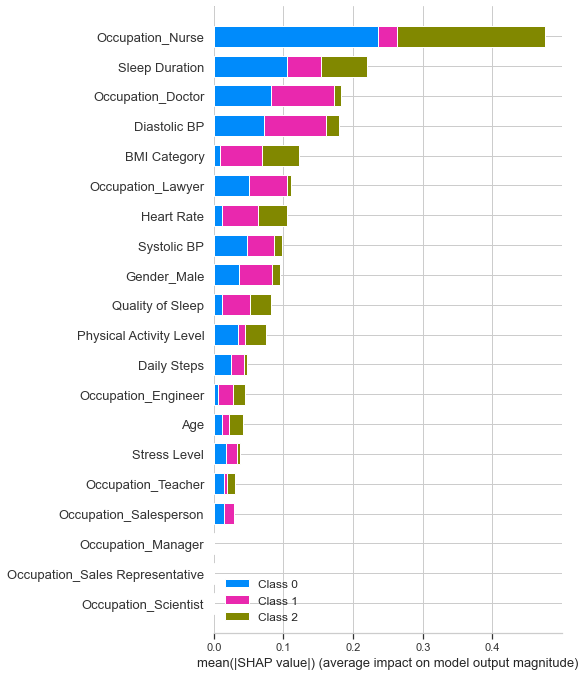

In [78]:
import shap
shap.initjs()

# Cargar el modelo calibrado desde disco
modelo_mlp = joblib.load('modelo_calibrado_mlp.joblib')

# Extraer el modelo base para usar con SHAP
modelo_mlp_base = modelo_mlp.base_estimator

# Seleccionar un subconjunto pequeño de test
X_shap = X_test.sample(15, random_state=42)

# Crear el KernelExplainer
explainer_mlp = shap.KernelExplainer(modelo_mlp_base.predict_proba, X_shap)
shap_values_mlp = explainer_mlp.shap_values(X_shap)

# Mostrar importancia global
shap.summary_plot(shap_values_mlp, X_shap, plot_type="bar")

# Explicación individual
shap.force_plot(explainer_mlp.expected_value[0], shap_values_mlp[0][0, :], X_shap.iloc[0])


X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names


  0%|          | 0/50 [00:00<?, ?it/s]

X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted

X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted

X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted

X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted

X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted

X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names
X does not have valid feature names, but MLPClassifier was fitted with feature names


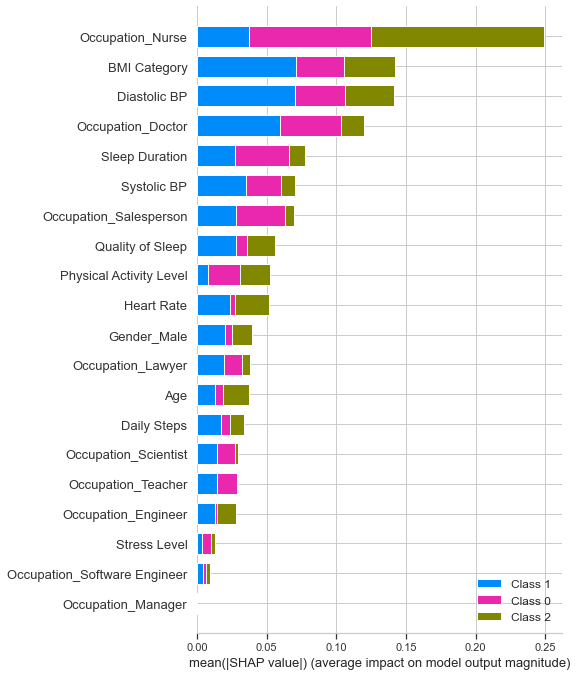

In [79]:
# Cargar el modelo MLP calibrado
modelo_mlp = joblib.load('modelo_calibrado_mlp.joblib')

# Seleccionar un subconjunto pequeño para que no tarde mucho
X_shap = X_test.sample(50, random_state=42)

# Crear el KernelExplainer para MLP
explainer_mlp = shap.KernelExplainer(modelo_mlp.predict_proba, X_shap)
shap_values_mlp = explainer_mlp.shap_values(X_shap)

# --- Importancia global de variables ---
shap.summary_plot(shap_values_mlp, X_shap, plot_type="bar")

# --- Explicación individual (opcionalmente una muestra) ---
shap.force_plot(explainer_mlp.expected_value[0], shap_values_mlp[0][0, :], X_shap.iloc[0])


In [80]:
# Probabilidades simuladas de predicción con Random Forest
# Para los tres casos clínicos evaluados
datos_comparativos = pd.DataFrame({
    "Clase esperada": ["Sleep Apnea", "Insomnia", "None"],
    "Predicción": ["Sleep Apnea", "Sleep Apnea", "Sleep Apnea"],
    "Prob. Insomnia": [0.075, 0.125, 0.150],
    "Prob. None": [0.133, 0.361, 0.368],
    "Prob. Sleep Apnea": [0.662, 0.514, 0.481]
})

# Mostrar tabla
datos_comparativos

,Clase esperada,Predicción,Prob. Insomnia,Prob. None,Prob. Sleep Apnea
0,Sleep Apnea,Sleep Apnea,0.075,0.133,0.662
1,Insomnia,Sleep Apnea,0.125,0.361,0.514
2,None,Sleep Apnea,0.150,0.368,0.481


In [85]:
import joblib
import os
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Asegúrate de que estas variables existen (sustitúyelas si hace falta)
# X_test, y_test deben estar definidos en tu notebook
assert 'X_test' in locals(), "⚠️ No se encontró X_test. Define primero tus datos de test."
assert 'y_test' in locals(), "⚠️ No se encontró y_test. Define primero tus datos de test."

# Rutas relativas a la carpeta notebooks (ajusta si estás en otra)
ruta_modelos = "../notebooks"

# Lista de modelos a evaluar
modelos = {
    "Random Forest calibrado": "modelo_calibrado_rf.joblib",
    "MLP calibrado": "modelo_calibrado_mlp.joblib",
    "Logistic Regression": "logistic_regression_model.joblib",
    "Decision Tree": "decision_tree_model.joblib",
    "SVM calibrado": "modelo_svm_calibrado.pkl"
}

print("🔍 Evaluación de modelos sobre X_test:\n")

for nombre, archivo in modelos.items():
    ruta_completa = os.path.join(ruta_modelos, archivo)
    try:
        modelo = joblib.load(ruta_completa)
        y_pred = modelo.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        print(f"🧠 Modelo: {nombre}")
        print(f"   Accuracy: {acc:.3f}")
        print(f"   F1-score macro: {f1:.3f}")
        print("   Classification report:")
        print(classification_report(y_test, y_pred, zero_division=0))
        print("-" * 70)
    except Exception as e:
        print(f"❌ Error con {nombre} ({archivo}): {e}")


🔍 Evaluación de modelos sobre X_test:

🧠 Modelo: Random Forest calibrado
   Accuracy: 0.960
   F1-score macro: 0.935
   Classification report:
              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.96        75
   macro avg       0.94      0.93      0.94        75
weighted avg       0.96      0.96      0.96        75

----------------------------------------------------------------------
🧠 Modelo: MLP calibrado
   Accuracy: 0.933
   F1-score macro: 0.915
   Classification report:
              precision    recall  f1-score   support

    Insomnia       0.93      0.87      0.90        15
        None       0.98      0.95      0.97        44
 Sleep Apnea       0.83      0.94      0.88        16

    accuracy                           0.93        75
   macro avg       0.91      0.92      

In [86]:
columnas_entrenamiento = X_train.columns.tolist()
joblib.dump(columnas_entrenamiento, "columnas_entrenamiento.joblib")

['columnas_entrenamiento.joblib']